# Музыкальные рекомендации: откуда берётся прирост и какая его часть настоящая

**Задача.** По истории прослушиваний Last.fm отранжировать треки под пользователя
на следующую неделю — и честно измерить, что именно работает.

**Зачем.** Рекомендации в музыкальных сервисах часто подсовывают либо то, что человек
и так слушал сто раз, либо усреднённый популярный трек: вроде и в жанре, но мимо.
Вопрос проекта — можно ли по истории прослушиваний ранжировать точнее и, главное,
как **честно измерить**, попадает ли модель на самом деле. Довольно быстро выяснилось,
что интересная часть задачи — не «обучить модель», а «понять, из чего складывается
её метрика». Об этом весь ноутбук.

**Чего проект не утверждает.** Это не продакшен-рекомендатель и не попытка обогнать
Spotify. Точка отсчёта — простые бейзлайны на открытых данных. Цель — показать, что
наивный прирост на поведенческих данных может быть **частично фальшивым**, и отделить
настоящий сигнал от смещения.

**Содержание.**
1. Данные — и где они на самом деле заканчиваются
2. Постановка: сплит по времени, повторы и открытия, метка
3. Метрики руками и две развилки, которые библиотека решает молча
4. Кандидаты, признаки и аудит утечек
5. Три бейзлайна и потолок воронки
6. CatBoost YetiRank
7. Разбор смещений: откуда взялся прирост
8. Дебайас: две попытки и почему они не сработали
9. Итоги, бутстрап, разбор ошибок руками
10. Что дальше и какой A/B поставить

Весь ноутбук считается на CPU. Полный прогон с нуля — около получаса на ноутбуке
(M1 Pro), из них большая часть — скачивание и парсинг датасета.

### Оговорка про смещения: чего здесь измерить нельзя

Классическая история про клики — это **position bias**, смещение позиции: люди кликают то,
что показано выше, а не обязательно то, что лучше. Лечат его двумя связанными вещами.
Кликовыми моделями — например, PBM (position-based model), которая раскладывает клик
на «человек вообще досмотрел до этой строки» и «строка ему понравилась». И перевзвешиванием
через IPW (inverse propensity weighting): клику по десятой позиции дают больший вес,
чем клику по первой, потому что до десятой ещё надо долистать. Подробнее про IPW —
в разделе про дебайас, там он понадобится по делу.

**В этих данных position bias не наблюдаем, и делать вид, что мы его меряем, нельзя.**
Last.fm-1K — это логи *прослушиваний*, а не логи *показов*. Мы видим, что человек послушал,
но не видим, что ему в этот момент показывали, в каком порядке и показывали ли вообще.
Без логов показов нет ни позиции, ни propensity — восстанавливать их из воздуха
значит просто придумывать данные.

Поэтому дальше разбираются два смещения, которые в этих данных **реально есть**:

| Смещение | В чём суть | Почему это аналог position bias |
|---|---|---|
| **popularity / exposure bias** | Популярные треки чаще попадаются на глаза, а не обязательно больше нравятся | Та же логика «наблюдаемость ≠ качество», только роль позиции играет популярность |
| **repeat bias** | Повторы знакомого забивают метрику и маскируют неспособность модели находить новое | Тот же замкнутый круг: система учится на том, что сама же и подсунула, и с каждым шагом сужает выдачу |

Осознанно заменить неизмеримое на измеримое — честнее, чем натянуть имитацию position bias
на данные, в которых его не видно.

---
### Окружение

In [1]:
import os, sys, json, time, hashlib, pathlib, tarfile, urllib.request, datetime as dt
from datetime import timedelta

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from catboost import CatBoostRanker, Pool

SEED = 42
N_THREADS = 6        # CatBoost детерминирован при фиксированном числе потоков; числа ниже — при 6

ROOT = pathlib.Path.cwd()
DATA = ROOT / "data"
RAW, PROC, CACHE = DATA / "raw", DATA / "processed", DATA / "cache"
FIG = ROOT / "figures"
for p in (RAW, PROC, CACHE, FIG):
    p.mkdir(parents=True, exist_ok=True)

pl.Config.set_tbl_rows(25)

# Единый вид графиков: светлый фон, тонкие линии, приглушённая сетка.
# Цвет закреплён за сущностью: повторы — синий, открытия — оранжевый во всём ноутбуке.
INK, INK_2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
BLUE, ORANGE, AQUA, VIOLET, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#a3a29d"
C_REPEAT, C_NEW, C_HEAD, C_TAIL = BLUE, ORANGE, AQUA, VIOLET
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 9.5, "xtick.color": INK_2, "ytick.color": INK_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.markersize": 7,
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
})


def save(fig, name):
    """Сохраняет график в figures/ — оттуда их берёт README."""
    fig.savefig(FIG / f"{name}.png")


print("polars", pl.__version__, "| numpy", np.__version__)

polars 1.42.1 | numpy 2.5.1


---
## 1. Данные

**Last.fm-1K** ([оригинальная страница](http://ocelma.net/MusicRecommendationDataset/lastfm-1K.html),
[зеркало на Zenodo](https://zenodo.org/records/6090214)) — полные истории прослушиваний
992 пользователей, собранные через `user.getRecentTracks` и обрезанные 5 мая 2009 года.
По README: **19 150 868 строк**. Одна строка — одно прослушивание:

```
userid \t timestamp \t musicbrainz-artist-id \t artist-name \t musicbrainz-track-id \t track-name
```

Лицензия — некоммерческое использование, для пет-проекта подходит.

Пара практических деталей, которые всплыли при парсинге:

* `musicbrainz-track-id` очень часто пустой, так что идентификатором трека берём
  нормализованную пару «артист + название» (нижний регистр, обрезанные пробелы).
  Это склеивает часть дублей и не разваливает каталог там, где MBID не проставили.
* В названиях треков полно кавычек, поэтому CSV-парсер надо запускать с `quote_char=None`,
  иначе он молча съедет по колонкам на первой же строке вида `Don"t`.

In [2]:
URL = "https://zenodo.org/api/records/6090214/files/lastfm-dataset-1K.tar.gz/content"
TGZ = RAW / "lastfm-dataset-1K.tar.gz"
TSV = RAW / "lastfm-dataset-1K" / "userid-timestamp-artid-artname-traid-traname.tsv"
MD5_TSV = "64747b21563e3d2aa95751e0ddc46b68"          # из README датасета

if not TSV.exists():
    if not TGZ.exists():
        print("скачиваем ~673 MB с Zenodo...")
        urllib.request.urlretrieve(URL, TGZ)
    print("распаковываем...")
    with tarfile.open(TGZ) as t:
        t.extractall(RAW)

def md5_of(path, chunk=1 << 22):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()

print(f"TSV на месте: {TSV.stat().st_size/1e9:.2f} GB")
# Проверка целостности — раскомментировать при первом запуске (считается ~30 секунд)
# assert md5_of(TSV) == MD5_TSV, "MD5 не сошёлся, файл битый"

TSV на месте: 2.53 GB


### Парсинг в parquet

Строки в целочисленные id, результат — на диск. 19 миллионов строк с полными названиями
треков — это 2.5 GB текста; после нормализации и перевода в int32 получается компактный
parquet, который читается за секунды. Все дальнейшие ячейки перезапускаются независимо.

In [3]:
EVENTS = PROC / "events.parquet"
TRACKS = PROC / "tracks.parquet"

if not EVENTS.exists():
    t0 = time.time()
    lf = pl.scan_csv(
        TSV, separator="\t", has_header=False,
        new_columns=["user_id", "ts", "artist_mbid", "artist", "track_mbid", "track"],
        quote_char=None,          # в названиях треков полно кавычек
        infer_schema_length=0,    # всё строками, кастуем сами
        truncate_ragged_lines=True, encoding="utf8-lossy",
    )
    n_raw = lf.select(pl.len()).collect().item()

    ev = (lf.with_columns(pl.col("ts").str.to_datetime("%Y-%m-%dT%H:%M:%SZ", strict=False))
            .filter(pl.col("ts").is_not_null()
                    & pl.col("artist").is_not_null() & (pl.col("artist").str.strip_chars() != "")
                    & pl.col("track").is_not_null() & (pl.col("track").str.strip_chars() != ""))
            .with_columns(
                artist_key=pl.col("artist").str.strip_chars().str.to_lowercase(),
                track_key=(pl.col("artist").str.strip_chars().str.to_lowercase()
                           + "␟" + pl.col("track").str.strip_chars().str.to_lowercase()))
            .select("user_id", "ts", "artist_key", "track_key", "artist", "track")
            .collect(engine="streaming"))

    tracks = (ev.group_by("track_key")
                .agg(artist_key=pl.col("artist_key").first(), artist=pl.col("artist").first(),
                     track=pl.col("track").first(), n=pl.len())
                .sort("n", descending=True).with_row_index("track_id"))
    artists = tracks.select("artist_key").unique().sort("artist_key").with_row_index("artist_id")
    tracks = tracks.join(artists, on="artist_key").with_columns(
        pl.col("track_id").cast(pl.Int32), pl.col("artist_id").cast(pl.Int32))
    users = ev.select("user_id").unique().sort("user_id").with_row_index("user_idx").with_columns(
        pl.col("user_idx").cast(pl.Int32))

    (ev.join(tracks.select("track_key", "track_id", "artist_id"), on="track_key")
       .join(users, on="user_id")
       .select("user_idx", "ts", "track_id", "artist_id")
       .sort("user_idx", "ts")
       .write_parquet(EVENTS, compression="zstd"))
    tracks.select("track_id", "artist_id", "artist", "track", "n").write_parquet(TRACKS)
    users.write_parquet(PROC / "users.parquet")
    print(f"сырых строк {n_raw:,} -> после чистки {ev.height:,}  ({time.time()-t0:.0f}s)")

ev = pl.read_parquet(EVENTS)
tracks = pl.read_parquet(TRACKS)
track_artist = ev.select("track_id", "artist_id").unique(subset=["track_id"])

print(f"событий            {ev.height:,}")
print(f"юзеров             {ev['user_idx'].n_unique():,}")
print(f"уникальных треков  {ev['track_id'].n_unique():,}")
print(f"артистов           {ev['artist_id'].n_unique():,}")
print(f"период             {ev['ts'].min():%Y-%m-%d}  ..  {ev['ts'].max():%Y-%m-%d}")

событий            19,150,868
юзеров             992
уникальных треков  1,500,643
артистов           174,088


период             2005-02-14  ..  2013-09-29


### Как выглядят данные

In [4]:
(ev.head(5)
   .join(tracks.select("track_id", "artist", "track"), on="track_id")
   .select("user_idx", "ts", "artist", "track"))

user_idx,ts,artist,track
i32,datetime[μs],str,str
0,2006-08-13 14:17:40,"""Tommy Guerrero""","""Mission Flats"""
0,2006-08-13 14:10:43,"""Plaid & Bob Jaroc""","""The Return Of Super Barrio - E…"
0,2006-08-13 14:03:29,"""Plaid & Bob Jaroc""","""Zn Zero"""
0,2006-08-13 13:59:20,"""Plaid & Bob Jaroc""","""The Launching Of Big Face"""
0,2006-08-13 14:19:06,"""Artful Dodger""","""What You Gonna Do?"""


### Базовая статистика в картинках

Три графика, которые задают рамку всему дальнейшему.

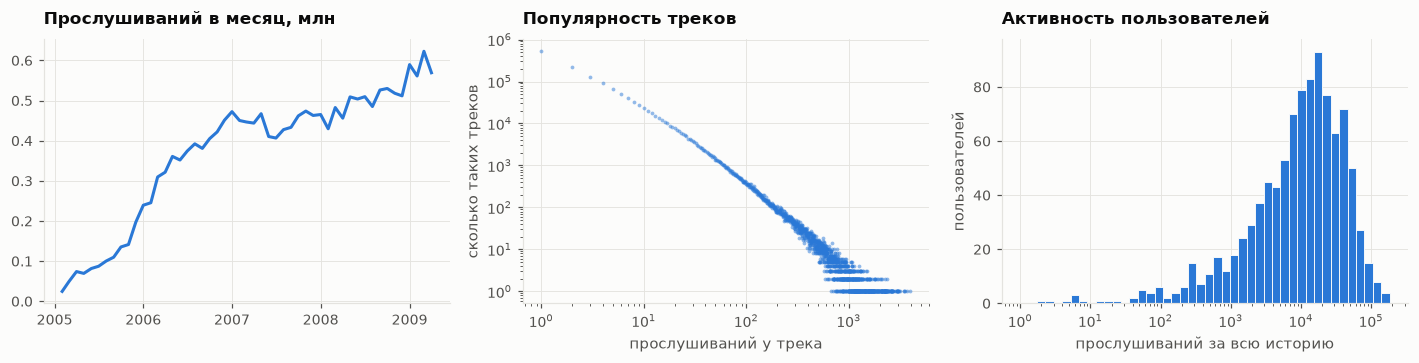

медиана прослушиваний на юзера: 11,551   мин 2   макс 183,103
на 1% самых популярных треков приходится 31.9% всех прослушиваний
треков, прослушанных ровно один раз: 35.0%


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))

# 1) события во времени. Строки позже мая 2009 — единичные события со сломанными часами
#    (подробнее ниже), на графике их нет.
by_month = (ev.filter((pl.col("ts") >= pl.datetime(2005, 1, 1)) & (pl.col("ts") < pl.datetime(2009, 5, 1)))
              .group_by(pl.col("ts").dt.truncate("1mo").alias("m")).agg(n=pl.len()).sort("m"))
ax[0].plot(by_month["m"], by_month["n"] / 1e6, color=BLUE)
ax[0].set_title("Прослушиваний в месяц, млн")
ax[0].xaxis.set_major_locator(mdates.YearLocator())
ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# 2) распределение популярности треков — лог-лог
pop_all = ev.group_by("track_id").agg(n=pl.len())["n"].to_numpy()
vals, cnts = np.unique(pop_all, return_counts=True)
ax[1].loglog(vals, cnts, "o", ms=2.5, alpha=0.5, color=BLUE, mec="none")
ax[1].set_title("Популярность треков")
ax[1].set_xlabel("прослушиваний у трека"); ax[1].set_ylabel("сколько таких треков")

# 3) активность юзеров
uact = ev.group_by("user_idx").agg(n=pl.len())["n"].to_numpy()
ax[2].hist(uact, bins=np.logspace(0, np.log10(uact.max()), 45), color=BLUE,
           edgecolor=SURFACE, linewidth=0.6)
ax[2].set_xscale("log")
ax[2].set_title("Активность пользователей")
ax[2].set_xlabel("прослушиваний за всю историю"); ax[2].set_ylabel("пользователей")
plt.tight_layout(); save(fig, "00-overview"); plt.show()

top_share = np.sort(pop_all)[::-1][:int(0.01 * len(pop_all))].sum() / pop_all.sum()
print(f"медиана прослушиваний на юзера: {np.median(uact):,.0f}   "
      f"мин {uact.min():,}   макс {uact.max():,}")
print(f"на 1% самых популярных треков приходится {top_share:.1%} всех прослушиваний")
print(f"треков, прослушанных ровно один раз: {(pop_all == 1).mean():.1%}")

Картина такая, какой и ждёшь от поведенческих данных: популярность распределена
по степенному закону (прямая в лог-лог координатах), у активности пользователей разброс
в три порядка, а огромная доля каталога — треки, прослушанные буквально один раз.

Это уже намекает на главную ловушку. Если метрика усредняется по прослушиваниям,
её почти целиком определяет голова распределения — и модель, которая просто выучила
«показывай популярное», будет выглядеть прилично.

### Где на самом деле заканчиваются данные

README обещает «истории до 5 мая 2009». Формально в данных есть события и после — вплоть
до 2013 года, но это единичные строки с явно сломанными часами. Интереснее другое:
**данные не обрываются, а затухают**, и это ломает наивный выбор тестового окна.

Посмотрим на две вещи сразу: сколько событий в день и у скольких юзеров этот день —
последний в их истории.

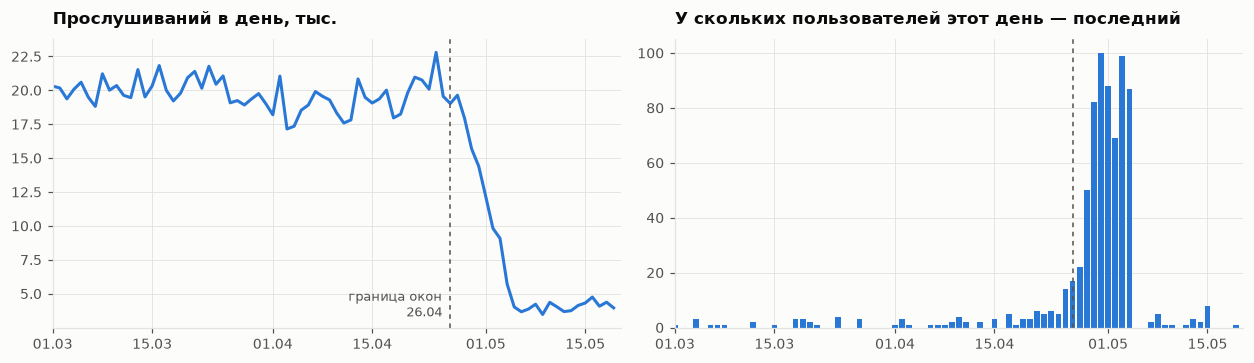

у 180 пользователей последняя строка позже 20 мая 2009 — это события со сломанными часами, на графике они не показаны


In [6]:
CUT, WIN = dt.date(2009, 4, 26), (dt.date(2009, 3, 1), dt.date(2009, 5, 20))
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.4))

daily = (ev.filter((pl.col("ts") >= pl.datetime(2009, 3, 1)) & (pl.col("ts") < pl.datetime(2009, 5, 20)))
           .group_by(pl.col("ts").dt.date().alias("d")).agg(n=pl.len()).sort("d"))
ax[0].plot(daily["d"], daily["n"] / 1000, color=BLUE)
ax[0].set_title("Прослушиваний в день, тыс.")

last_ev = ev.group_by("user_idx").agg(last=pl.col("ts").max())
ld = (last_ev.filter((pl.col("last") >= pl.datetime(2009, 3, 1)) & (pl.col("last") < pl.datetime(2009, 5, 20)))
             .group_by(pl.col("last").dt.date().alias("d")).agg(n=pl.len()).sort("d"))
ax[1].bar(ld["d"], ld["n"], width=0.8, color=BLUE)
ax[1].set_title("У скольких пользователей этот день — последний")

for a in ax:
    a.axvline(CUT, color=INK_2, ls=(0, (3, 3)), lw=1)
    a.set_xlim(*WIN)
    a.xaxis.set_major_locator(mdates.DayLocator(bymonthday=[1, 15]))
    a.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
ax[0].text(CUT, ax[0].get_ylim()[0] + 0.5, "граница окон  \n26.04  ", color=INK_2, fontsize=8.5,
           va="bottom", ha="right")
plt.tight_layout(); save(fig, "01-data-end"); plt.show()

late = last_ev.filter(pl.col("last") >= pl.datetime(2009, 5, 20)).height
print(f"у {late} пользователей последняя строка позже 20 мая 2009 — это события со сломанными "
      f"часами, на графике они не показаны")

Правый график — это, по сути, расписание работы краулера. С 28 апреля по 4 мая у примерно
600 из 992 пользователей внезапно «заканчивается жизнь». Люди, разумеется, не переставали
слушать музыку синхронно — просто сбор данных шёл по списку пользователей несколько дней,
и у каждого история обрывается в момент, когда до него дошла очередь.

Для нас это принципиально. Метка «юзер НЕ слушал этот трек в тестовом окне» в такой зоне
ничего не значит: может, и слушал, просто мы этого не видим. Модель получит штраф
за правильный ответ.

Считаем цену вопроса:

In [7]:
for T4_try in [dt.datetime(2009, 5, 5), dt.datetime(2009, 4, 26)]:
    T3_try = T4_try - timedelta(days=28)
    active = ev.filter((pl.col("ts") >= T3_try) & (pl.col("ts") < T4_try))["user_idx"].n_unique()
    censored = last_ev.filter((pl.col("last") >= T3_try) & (pl.col("last") < T4_try)).height
    print(f"тест [{T3_try:%Y-%m-%d}, {T4_try:%Y-%m-%d}):  активных юзеров {active},  "
          f"обрезаны краулером {censored} ({censored/active:.0%})")
print("\nПоэтому последнее тестовое окно заканчивается 26 апреля, а не 5 мая:")
print("недельный объём до этой даты держится ровно (~139 тыс. событий в неделю),")
print("а оставшиеся 10% — это уже настоящие «ушёл с сервиса», а не артефакт сбора.")

тест [2009-04-07, 2009-05-05):  активных юзеров 830,  обрезаны краулером 677 (82%)
тест [2009-03-29, 2009-04-26):  активных юзеров 712,  обрезаны краулером 69 (10%)

Поэтому последнее тестовое окно заканчивается 26 апреля, а не 5 мая:
недельный объём до этой даты держится ровно (~139 тыс. событий в неделю),
а оставшиеся 10% — это уже настоящие «ушёл с сервиса», а не артефакт сбора.


---
## 2. Постановка задачи ранжирования

### Сплит по времени, а не случайный

Случайное перемешивание здесь было бы прямой утечкой из будущего: модель обучалась бы
на прослушиваниях, которые произошли **после** тех, что она предсказывает. Метрика
получилась бы фейково красивой. Поэтому сплит строго по времени.

Одной отсечки мало. Нужны как минимум две: одна отделяет обучение модели, вторая — замер.
Иначе модель обучалась бы на том же окне, на котором её и проверяют. Схема (rolling origin):

```
           ← признаки ←|  метки  |
 TRAIN  ...............|▓▓▓▓▓▓▓▓▓|                              признаки < T1, метки [T1,T2)
           ← признаки ←..........|  метки  |
 VALID  ................▓▓▓▓▓▓▓▓▓|▓▓▓▓▓▓▓▓▓|                    признаки < T2, метки [T2,T3)
           ← признаки ←....................|  метки  |
 TEST   ................▓▓▓▓▓▓▓▓▓ ▓▓▓▓▓▓▓▓▓|▓▓▓▓▓▓▓▓▓|          признаки < T3, метки [T3,T4)
        ────────────────┬─────────┬─────────┬─────────→ время
                       T1        T2        T3        T4
```

Признаки для теста считаются по всему, что было до `T3`, — включая окно валидации.
Это не утечка: в момент `T3` эти данные уже существуют и в проде были бы доступны.

* **TRAIN** — на нём учится CatBoost.
* **VALID** — на нём подбирается число итераций и параметр дебайаса `η`. Трогать тест для
  подбора чего бы то ни было нельзя, иначе финальные числа — самообман.
* **TEST** — только финальный замер, один раз.

### Кандидаты

Полтора миллиона треков под каждого юзера не отранжируешь — как и в настоящем поиске,
нужна воронка: сначала быстро набрать несколько сотен правдоподобных вариантов,
и только их отдать на точное ранжирование. Источников пять, и подбирались они
не с первого раза (разбор ниже).

### Повторы и открытия: главное деление во всём ноутбуке

Каждого кандидата относим к одному из двух типов — по тому, слышал ли этот пользователь
этот трек **раньше**, до отсечки:

* **повтор** — трек уже есть в истории юзера;
* **открытие** — трек новый лично для него (в каталоге он мог существовать хоть двадцать лет).

Деление не косметическое. Примерно две трети того, что человек послушает на следующей
неделе, — это повторы. Значит, модель может набрать прекрасную метрику, вообще не умея
предлагать новое, и по общей цифре этого не увидишь. Дальше почти весь разбор строится
на том, чтобы смотреть на эти два типа отдельно.

Способ отбора определяет, какие треки источник в принципе способен принести:

| Источник | Что берёт | Может ли дать открытие |
|---|---|---|
| 1. история по свежести | что юзер слушал недавно | нет — по построению это его история |
| 2. история по частоте | что юзер слушает много | нет — то же самое |
| 3. co-occurrence | треки, которые у других людей встречаются рядом с недавними треками юзера | да, если сосед ему незнаком |
| 4. каталог знакомых артистов | популярные треки его артистов, которых он **не** слышал | только открытия — слышанное отсеивается явно |
| 5. глобальный топ | просто популярное, одинаковое для всех | да, если он этого хита ещё не слышал |

Первые два источника — чистые поставщики повторов, четвёртый — чистый поставщик открытий,
третий и пятый смешанные. Точные пропорции посчитаем ниже, когда кандидаты будут собраны.

### Метка

Кандидаты собраны, теперь надо сказать модели, какие из них были «правильными».
Метка простая: **1, если юзер послушал этот трек в окне меток, иначе 0.**

То есть для каждой пары «пользователь – кандидат» заглядываем в следующую неделю
(при обучении — можно, это прошлое относительно момента предсказания) и смотрим,
случилось это прослушивание или нет. Получается таблица примерно на 850 строк
на пользователя, где около 3% строк — единицы.

Дальше задача обычная для ранжирования: научиться так расставлять кандидатов по порядку,
чтобы единицы оказывались наверху. Оценивать это будем на пользователях как на группах —
сравнивать имеет смысл кандидатов внутри одной выдачи, а не треки разных людей между собой.

In [8]:
# Три окна меток по 7 дней подряд, последнее упирается в 26 апреля — дальше данные
# испорчены расписанием краулера (см. выше).
#
# Почему неделя, а не месяц: за месяц юзер успевает послушать ~280 разных треков,
# и предсказывать такое множество кандидатами разумного размера бессмысленно.
# За неделю это ~85 треков — задача, у которой есть решение.
T1 = dt.datetime(2009, 4,  5)
T2 = dt.datetime(2009, 4, 12)
T3 = dt.datetime(2009, 4, 19)
T4 = dt.datetime(2009, 4, 26)

WINDOWS = {"train": (T1, T1, T2), "valid": (T2, T2, T3), "test": (T3, T3, T4)}   # feat_end, label_start, label_end
for name, (fe, ls, le) in WINDOWS.items():
    n_ev = ev.filter((pl.col("ts") >= ls) & (pl.col("ts") < le)).height
    n_u = ev.filter((pl.col("ts") >= ls) & (pl.col("ts") < le))["user_idx"].n_unique()
    print(f"{name:6s} признаки < {fe:%Y-%m-%d} | метки [{ls:%Y-%m-%d}, {le:%Y-%m-%d})"
          f"   событий {n_ev:>9,}   активных юзеров {n_u:>4}")

train  признаки < 2009-04-05 | метки [2009-04-05, 2009-04-12)   событий   132,125   активных юзеров  612
valid  признаки < 2009-04-12 | метки [2009-04-12, 2009-04-19)   событий   134,545   активных юзеров  612
test   признаки < 2009-04-19 | метки [2009-04-19, 2009-04-26)   событий   142,245   активных юзеров  627


### Подвыборка пользователей

19 млн событий на ноутбуке пережить можно, но итерации становятся медленными. Беру
подвыборку пользователей — со всей их историей, с фиксированным seed, и сохраняю на диск,
чтобы все эксперименты шли на одинаковых данных.

Важная деталь: **отбираем юзеров по активности в обучающем периоде, а не в тестовом.**
Соблазн взять «тех, кто активен в тесте» велик — выборка получится плотнее и метрики
красивее, — но это отбор по будущему, то есть та же утечка, только на уровне популяции.
Сколько из отобранных реально доживёт до теста, посчитано ниже.

А вот **популярность и co-occurrence считаем по всем 992 юзерам** (по обучающему периоду).
Это не утечка: тестовое окно не трогается, а статистики от большего числа юзеров становятся
заметно надёжнее. В проде было бы ровно так же — каталожные статистики считают по всему
трафику, а не по подвыборке.

**Про `np.sort` в следующей ячейке.** Seed был зафиксирован, и казалось, что выборка
воспроизводима. Она не была. `group_by` в polars не обещает никакого порядка строк,
а `rng.choice` выбирает элементы по позициям в массиве — так что при одном и том же seed
получались разные 300 юзеров (пересечение — 98 из 300). Поймалось это не глазами,
а ассертом из аудита утечек ниже: он сравнивал признаки, посчитанные на полных и на урезанных
данных, и они не сходились. Искали утечку, а нашли вот это.

Это третий случай одной и той же ошибки в проекте: ничьи при сортировке скоров, ничьи
при отборе топ-50k треков и вот здесь. Везде причина одна — **порядок при равных значениях
нигде не задан явно**, и результат зависит от того, как лягут строки.

In [9]:
N_USERS = 300
MIN_TRAIN_EVENTS = 200          # минимальная история к моменту T1

# np.sort здесь не косметика. group_by в polars не гарантирует порядок строк,
# а rng.choice выбирает элементы ПО ПОЗИЦИЯМ — без сортировки один и тот же seed
# давал разную выборку от запуска к запуску (проверено: совпадало 98 юзеров из 300).
eligible = np.sort(ev.filter(pl.col("ts") < T1).group_by("user_idx").agg(n=pl.len())
                     .filter(pl.col("n") >= MIN_TRAIN_EVENTS)["user_idx"].to_numpy())
rng = np.random.default_rng(SEED)
USERS = np.sort(rng.choice(eligible, size=min(N_USERS, len(eligible)), replace=False))
pl.DataFrame({"user_idx": USERS}).write_parquet(PROC / "users_sample.parquet")

print(f"юзеров с историей >= {MIN_TRAIN_EVENTS} событий до T1: {len(eligible)} из {ev['user_idx'].n_unique()}")
print(f"в подвыборке: {len(USERS)}")
for name, (fe, ls, le) in WINDOWS.items():
    alive = (ev.filter((pl.col("ts") >= ls) & (pl.col("ts") < le)
                       & pl.col("user_idx").is_in(USERS))["user_idx"].n_unique())
    print(f"  из них активны в окне меток {name:6s}: {alive:3d}  ({alive/len(USERS):.0%})")

юзеров с историей >= 200 событий до T1: 937 из 992
в подвыборке: 300
  из них активны в окне меток train : 208  (69%)
  из них активны в окне меток valid : 207  (69%)
  из них активны в окне меток test  : 214  (71%)


---
## 3. Метрики: реализация руками

Готовую библиотеку сознательно не зовём — формулы надо понимать, а не импортировать.

**Общие обозначения** (дальше используются во всех формулах этого раздела):

* модель выдала пользователю список кандидатов, отсортированный по убыванию своего скора;
* $i$ — **номер позиции** в этом списке: $i = 1$ — самый верх выдачи;
* $k$ — **до какой позиции мы смотрим**. Для `NDCG@10` это $k=10$: всё, что ниже
  десятой строки, в метрику не попадает вообще. Так и в жизни — до сотой рекомендации
  никто не долистывает;
* $rel_i$ — **релевантность того, что стоит на позиции $i$**. У нас она двоичная:
  $rel_i = 1$, если этот трек пользователь в тестовом окне действительно послушал,
  и $rel_i = 0$, если нет;
* $R$ — **сколько всего правильных ответов у этого пользователя**, то есть сколько разных
  треков он послушал в тестовом окне. Про то, как именно считать $R$, будет отдельный
  разговор ниже — там прячется решение, которое легко проглядеть.

**DCG@k** («накопленная выгода с обесцениванием»). Складываем релевантности того,
что попало в топ-$k$, но каждую делим на логарифм её позиции:

$$\mathrm{DCG@k} = \sum_{i=1}^{k} \frac{rel_i}{\log_2(i+1)}$$

Логарифм — это модель убывающего внимания. Попадание на 1-й позиции приносит
$1/\log_2 2 = 1$, на 2-й — уже $1/\log_2 3 \approx 0.63$, на 10-й — $1/\log_2 11 \approx 0.29$.
То есть разница между первой и второй строкой весит больше, чем между девятой и десятой,
— как и должно быть.

**NDCG@k** («нормированный DCG»). У DCG есть неудобство: у активного пользователя,
который послушал 100 треков, он в принципе может быть выше, чем у того, кто послушал два.
Сравнивать таких пользователей напрямую бессмысленно. Поэтому DCG делят на DCG
**идеальной выдачи** — той, где все правильные ответы стоят подряд с самого верха:

$$\mathrm{NDCG@k} = \frac{\mathrm{DCG@k}}{\mathrm{IDCG@k}}, \qquad
  \mathrm{IDCG@k} = \sum_{i=1}^{\min(k,\,R)} \frac{1}{\log_2(i+1)}$$

Здесь $\min(k, R)$ означает «меньшее из двух». Если правильных ответов больше, чем позиций
($R \geq k$), идеал — это $k$ единиц подряд. Если меньше ($R < k$), то идеал — $R$ единиц,
больше взять неоткуда. После деления NDCG всегда лежит между 0 и 1: единица — все правильные
ответы наверху, ноль — ни одного в топ-$k$.

**MRR** (mean reciprocal rank, «средний обратный ранг») — единица, делённая на позицию
первого правильного ответа. Первый на 1-й строке — 1.0, на 4-й — 0.25, вообще нет в выдаче — 0.
Отвечает на вопрос «как быстро пользователь увидит хоть что-то нужное».

**Recall@k** («полнота») — какая доля правильных ответов попала в топ-$k$: число попаданий
среди первых $k$, делённое на $R$. Это метрика **кандидатогенерации**, а не ранжирования:
она про то, достали ли мы нужное вообще, а не про то, в каком порядке разложили.

Все три метрики считаем **для каждого пользователя отдельно, а потом усредняем по
пользователям**. Не по прослушиваниям: иначе один человек с гигантской историей
перевесил бы сотню обычных.

### Что считать за $R$: решение, которое легко проглядеть

$R$ — это число правильных ответов у пользователя, то есть сколько треков он реально
послушал в окне меток. Оно стоит в IDCG, а IDCG — это «сколько набрал бы идеальный
ранжировщик». Вот тут и обнаруживается развилка.

Воронка достаёт не все правильные ответы. Пусть юзер послушал 40 треков, а в список
из 850 кандидатов попало 10 из них. Оставшиеся 30 модель не поднимет наверх никогда —
их просто нет в списке. Что писать в $R$?

* **$R$ = только попавшие в кандидатов.** Идеалом считается «поднять наверх всё, что
  достали». Недостающие 30 треков из метрики исчезают: их как будто и не существовало.
  Меряется чистое качество ранжирования, промахи воронки не видны.
* **$R$ = все правильные ответы юзера.** Идеалом считается «угадать все 40».
  Метрика становится сквозной: не достали трек — получите штраф.

Берём второй вариант: пользователю всё равно, на каком этаже воронки его потеряли.

**Но важно понимать, где этот выбор реально что-то меняет, а где нет** — иначе легко
приписать ему больше, чем он делает. IDCG@k суммируется по $\\min(k, R)$ слагаемым,
то есть обрезается на $k$. Значит, при $R \\geq 10$ **оба варианта дают ровно одно и то же**.
Разница появляется только у пользователей, у которых правильных ответов меньше десяти.

In [10]:
_d = lambda n: sum(1 / np.log2(i + 2) for i in range(n))

print("юзер послушал 40 треков, достали 10, модель поставила все 10 наверх:")
print(f"   R=10  -> IDCG@10 = {_d(10):.3f}, NDCG@10 = {_d(10)/_d(10):.3f}")
print(f"   R=40  -> IDCG@10 = {_d(10):.3f}, NDCG@10 = {_d(10)/_d(10):.3f}   <- то же самое")
print("\nа теперь юзер послушал 4 трека, достали 1, модель поставила её первой:")
print(f"   R=1   -> IDCG@10 = {_d(1):.3f}, NDCG@10 = {1/_d(1):.3f}   <- «идеально», хотя нашли четверть")
print(f"   R=4   -> IDCG@10 = {_d(4):.3f}, NDCG@10 = {1/_d(4):.3f}   <- честнее")

юзер послушал 40 треков, достали 10, модель поставила все 10 наверх:
   R=10  -> IDCG@10 = 4.544, NDCG@10 = 1.000
   R=40  -> IDCG@10 = 4.544, NDCG@10 = 1.000   <- то же самое

а теперь юзер послушал 4 трека, достали 1, модель поставила её первой:
   R=1   -> IDCG@10 = 1.000, NDCG@10 = 1.000   <- «идеально», хотя нашли четверть
   R=4   -> IDCG@10 = 2.562, NDCG@10 = 0.390   <- честнее


Где это бьёт в нашем случае, посчитаем чуть позже — когда кандидаты будут собраны
(раздел «Цена выбора $R$» перед разбором воронки). Забегая вперёд: на общий NDCG@10
это влияет слабо, на Recall@50 — всегда, а на срезе открытий определяет,
по каким юзерам метрика вообще посчитается.

In [11]:
def dcg(rels, k):
    """DCG@k. rels — метки В ПОРЯДКЕ ВЫДАЧИ."""
    rels = np.asarray(rels, dtype=float)[:k]
    if rels.size == 0:
        return 0.0
    return float(np.sum(rels / np.log2(np.arange(2, rels.size + 2))))

def ndcg_at_k(ranked_labels, n_relevant_total, k=10):
    if n_relevant_total <= 0:
        return np.nan
    return dcg(ranked_labels, k) / dcg(np.ones(min(k, n_relevant_total)), k)

def mrr(ranked_labels):
    hits = np.flatnonzero(np.asarray(ranked_labels) > 0)
    return 1.0 / (hits[0] + 1) if hits.size else 0.0

def recall_at_k(ranked_labels, n_relevant_total, k=50):
    if n_relevant_total <= 0:
        return np.nan
    return float(np.sum(np.asarray(ranked_labels)[:k] > 0)) / n_relevant_total

### Проверка на игрушечном примере

Считаем то же самое на бумаге и сверяем. Выдача из 5 позиций, релевантны 2-я и 4-я:

* $\mathrm{DCG@3} = \frac{0}{\log_2 2} + \frac{1}{\log_2 3} + \frac{0}{\log_2 4} = 0.6309$
* $\mathrm{IDCG@3} = \frac{1}{\log_2 2} + \frac{1}{\log_2 3} = 1.6309$
* $\mathrm{NDCG@3} = 0.6309 / 1.6309 = 0.3869$
* MRR: первый релевантный на 2-й позиции → $1/2 = 0.5$
* Recall@3: нашли 1 из 2 → $0.5$

In [12]:
labels, n_rel = [0, 1, 0, 1, 0], 2
print(f"DCG@3   = {dcg(labels,3):.4f}   (на бумаге 0.6309)")
print(f"NDCG@3  = {ndcg_at_k(labels,n_rel,3):.4f}   (на бумаге 0.3869)")
print(f"MRR     = {mrr(labels):.4f}   (на бумаге 0.5000)")
print(f"R@3     = {recall_at_k(labels,n_rel,3):.4f}   (на бумаге 0.5000)")

assert abs(dcg(labels, 3) - 0.6309297535714575) < 1e-12
assert abs(ndcg_at_k(labels, n_rel, 3) - 0.38685280723454163) < 1e-12
assert abs(mrr(labels) - 0.5) < 1e-12
assert abs(recall_at_k(labels, n_rel, 3) - 0.5) < 1e-12
assert ndcg_at_k([1, 1, 0, 0, 0], 2, 3) == 1.0          # идеальная выдача
assert ndcg_at_k([0, 0, 0, 1, 1], 2, 3) == 0.0          # всё релевантное ниже k
# сквозной режим: у юзера 2 позитива, кандидатогенерация достала только один
assert abs(ndcg_at_k([1, 0, 0], 2, 3) - 1 / 1.6309297535714575) < 1e-12
print("\nвсе проверки прошли")

DCG@3   = 0.6309   (на бумаге 0.6309)
NDCG@3  = 0.3869   (на бумаге 0.3869)
MRR     = 0.5000   (на бумаге 0.5000)
R@3     = 0.5000   (на бумаге 0.5000)

все проверки прошли


### Ничьи: место, где метрика врёт особенно охотно

Отдельная ячейка ради одной мысли, которая в статьях обычно проговаривается мелким шрифтом.

У бейзлайна «личное повторение» все незнакомые юзеру треки получают score = 0 — то есть
сотни кандидатов идут в одну ничью. Как их отсортирует `argsort`? В том порядке, в каком
они лежали в списке кандидатов. А список собирается «сначала история юзера, потом остальное».
История коррелирует с будущим прослушиванием — и метрика взлетает **на пустом месте**,
не из-за модели, а из-за порядка строк в DataFrame.

Лечится перемешиванием перед сортировкой. Ниже — цена вопроса на синтетическом примере,
где все скоры равны, а позитивы стоят первыми в списке кандидатов.

In [13]:
def rank_with_random_ties(scores, rng):
    """Порядок по убыванию score со случайным разрывом ничьих."""
    scores = np.asarray(scores, dtype=float)
    perm = rng.permutation(scores.size)
    return perm[np.argsort(-scores[perm], kind="stable")]

_lab, _sc = np.array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0]), np.zeros(10)
_rng = np.random.default_rng(0)
naive = np.mean([ndcg_at_k(_lab[np.argsort(-_sc, kind="stable")], 2, 3) for _ in range(500)])
fair  = np.mean([ndcg_at_k(_lab[rank_with_random_ties(_sc, _rng)], 2, 3) for _ in range(500)])
print(f"все скоры равны, позитивы первые в списке кандидатов:")
print(f"  стабильная сортировка (баг):  NDCG@3 = {naive:.3f}")
print(f"  случайный разрыв ничьих:      NDCG@3 = {fair:.3f}")
print("\nразница целиком фиктивная — это порядок строк, а не качество ранжирования")

все скоры равны, позитивы первые в списке кандидатов:
  стабильная сортировка (баг):  NDCG@3 = 1.000
  случайный разрыв ничьих:      NDCG@3 = 0.275

разница целиком фиктивная — это порядок строк, а не качество ранжирования


---
## 4. Кандидаты, признаки и аудит утечек

Кандидатогенерация и признаки собраны в одном разделе: бейзлайны считаются по тем же
подготовленным таблицам, так что собрать их удобнее один раз.

### Кандидатогенерация

### Co-occurrence: «эти треки слушают рядом друг с другом»

Идея простая. Если у многих людей трек A и трек B регулярно оказываются в плейлисте
по соседству, значит, между ними есть связь — жанровая, настроенческая, какая угодно.
Тогда человеку, который только что послушал A, имеет смысл предложить B. Никакого
обучения тут нет, просто подсчёт совпадений по истории.

**Что считается соседством.** Берём историю каждого пользователя, упорядоченную по времени,
и объявляю два трека соседями, если между ними не больше **трёх позиций** в этой
последовательности и не больше **30 минут** по часам. Тридцать минут — грубая граница
сессии: если человек ушёл и вернулся через два часа, это уже другое прослушивание,
и связывать последний трек вечера с первым треком утра незачем.

**Обозначения.** Для пары треков $a$ и $b$:

* $c_{ab}$ — **сколько раз** эти два трека оказались соседями. Считается по всем
  пользователям сразу, по обучающему периоду. Скажем, $c_{ab} = 400$ означает,
  что за весь обучающий период эта пара встретилась рядом 400 раз.
* $n_a$ — **сколько всего раз слушали трек $a$** (его популярность), $n_b$ — то же для $b$.

Итоговая близость:

$$\mathrm{sim}(a,b) = \frac{c_{ab}}{\sqrt{n_a \cdot n_b}}$$

**Зачем делить.** Само по себе $c_{ab}$ обманчиво. У самого популярного трека в датасете
несколько сотен тысяч прослушиваний, поэтому он оказывается рядом со всем подряд —
просто потому, что он везде. Если ранжировать соседей по сырому $c_{ab}$, то лучшим
«соседом» любого трека окажется главный хит датасета, и co-occurrence превратится
в переодетую популярность.

Деление на $\sqrt{n_a n_b}$ это лечит: чем чаще трек звучит вообще, тем больше знаменатель.
Формула отвечает уже не на вопрос «сколько раз они встретились рядом», а на вопрос
«встретились ли они рядом чаще, чем ожидалось бы от их популярности». Это та же
косинусная мера, что в текстовом поиске, только вместо слов — треки.

**Практическое ограничение.** Пар в полном каталоге получилось бы слишком много для памяти
ноутбука, поэтому co-occurrence считаем только среди 50 тысяч самых популярных треков.
Хвост в кандидаты всё равно не попадёт, а задача уменьшается на порядки.

In [14]:
SESSION_GAP_S, COOC_LAGS, RECENT_DAYS, N_SEEDS = 1800, (1, 2, 3), 30, 30

def build_global_stats(ev, feat_end, top_n_tracks=50_000):
    """Каталожные статистики по ВСЕМ юзерам, но строго по периоду < feat_end."""
    train = ev.filter(pl.col("ts") < feat_end)
    recent_start = feat_end - timedelta(days=RECENT_DAYS)

    # Вторичный ключ track_id обязателен: на границе топ-50k стоят сотни треков с одинаковой
    # популярностью, и без него sort разбивает ничью по-разному от запуска к запуску —
    # граф co-occurrence и кандидаты перестают быть воспроизводимыми.
    pop = (train.group_by("track_id").agg(pop=pl.len(), pop_users=pl.col("user_idx").n_unique())
                .sort(["pop", "track_id"], descending=[True, False]))
    pop = (pop.join(train.filter(pl.col("ts") >= recent_start)
                         .group_by("track_id").agg(pop_recent=pl.len()), on="track_id", how="left")
              .with_columns(pl.col("pop_recent").fill_null(0)))
    artist_pop = train.group_by("artist_id").agg(artist_pop=pl.len())

    tr = (train.join(pop.head(top_n_tracks).select("track_id"), on="track_id", how="semi")
               .select("user_idx", "ts", "track_id").sort("user_idx", "ts"))
    parts = []
    for lag in COOC_LAGS:
        parts.append(
            tr.with_columns(nxt=pl.col("track_id").shift(-lag).over("user_idx"),
                            nxt_ts=pl.col("ts").shift(-lag).over("user_idx"))
              .filter(pl.col("nxt").is_not_null() & (pl.col("nxt") != pl.col("track_id"))
                      & ((pl.col("nxt_ts") - pl.col("ts")).dt.total_seconds() <= SESSION_GAP_S))
              .select(a=pl.min_horizontal("track_id", "nxt"), b=pl.max_horizontal("track_id", "nxt")))
    cooc = (pl.concat(parts).group_by("a", "b").agg(c=pl.len())
              .filter(pl.col("c") >= 2))                  # одиночные пары — шум
    popm = pop.select("track_id", "pop")
    cooc = (cooc.join(popm.rename({"track_id": "a", "pop": "pa"}), on="a")
                .join(popm.rename({"track_id": "b", "pop": "pb"}), on="b")
                .with_columns(sim=pl.col("c") / (pl.col("pa") * pl.col("pb")).sqrt())
                .select("a", "b", "c", "sim"))
    cooc = pl.concat([cooc.select(src="a", dst="b", c="c", sim="sim"),      # симметризуем
                      cooc.select(src="b", dst="a", c="c", sim="sim")])
    return {"pop": pop, "artist_pop": artist_pop, "cooc": cooc,
            "feat_end": feat_end, "recent_start": recent_start}

def _seeds(hist, n_seeds=N_SEEDS):
    return (hist.sort(["ts", "track_id"], descending=[True, False])
                .unique(subset=["user_idx", "track_id"], keep="first")
                .sort(["ts", "track_id"], descending=[True, False])
                .group_by("user_idx").head(n_seeds)
                .select("user_idx", src="track_id"))

def cooc_scores(hist, stats, n_seeds=N_SEEDS):
    """Score для КАЖДОЙ пары (юзер, трек) — независимо от того, попал ли трек в кандидатов.
    Иначе признак превратился бы в скрытый флаг «я из источника co-occurrence»."""
    return (_seeds(hist, n_seeds).join(stats["cooc"], on="src", how="inner")
            .group_by("user_idx", "dst")
            .agg(cooc_sim=pl.col("sim").sum(), cooc_cnt=pl.col("c").sum())
            .rename({"dst": "track_id"}))

### Пять источников кандидатов

Первая версия отбирала историю юзера по числу прослушиваний — и оказалась плохой.
Библиотеки здесь огромные (медиана 3.5 тысячи разных треков), и то, что человек слушает
на следующей неделе, размазано по всей библиотеке, а не сидит в личном топе.
Отбор **по свежести** работает заметно лучше отбора по частоте, поэтому берём оба.

Плюс отдельный источник, без которого в музыке никуда: **непрослушанные треки тех артистов,
которых юзер уже слушает.** Это главный реалистичный канал открытий — 64% всех новых для
юзера треков принадлежат артистам из его истории.

In [15]:
def build_candidates(ev, users, stats, n_recent=250, n_freq=150, n_cooc=200, n_pop=100,
                     top_artists=60, tracks_per_artist=12, max_cand=None):
    feat_end = stats["feat_end"]
    uu = pl.DataFrame({"user_idx": np.asarray(sorted(users), dtype=np.int32)})
    hist = ev.filter(pl.col("ts") < feat_end).join(uu, on="user_idx", how="semi")
    agg = hist.group_by("user_idx", "track_id").agg(cnt=pl.len(), last=pl.col("ts").max())

    # 1) история по свежести, 2) история по частоте
    src_recent = (agg.sort(["last", "track_id"], descending=[True, False])
                     .group_by("user_idx").head(n_recent)
                     .select("user_idx", "track_id").with_columns(from_recent=pl.lit(1, dtype=pl.Int8)))
    src_freq = (agg.sort(["cnt", "track_id"], descending=[True, False])
                   .group_by("user_idx").head(n_freq)
                   .select("user_idx", "track_id").with_columns(from_freq=pl.lit(1, dtype=pl.Int8)))
    # 3) соседи по co-occurrence
    src_cooc = (cooc_scores(hist, stats).sort(["cooc_sim", "track_id"], descending=[True, False])
                .group_by("user_idx").head(n_cooc).select("user_idx", "track_id")
                .with_columns(from_cooc=pl.lit(1, dtype=pl.Int8)))
    # 4) глобальный топ — одинаковый для всех
    src_pop = uu.join(stats["pop"].head(n_pop).select("track_id")
                        .with_columns(from_pop=pl.lit(1, dtype=pl.Int8)), how="cross")
    # 5) каталог знакомых артистов: их популярные треки, которых юзер ещё не слышал
    art_rank = (hist.group_by("user_idx", "artist_id").agg(n=pl.len())
                    .sort(["user_idx", "n", "artist_id"], descending=[False, True, False])
                    .with_columns(r=pl.int_range(pl.len()).over("user_idx") + 1)
                    .filter(pl.col("r") <= top_artists))
    catalogue = (ev.filter(pl.col("ts") < feat_end).group_by("artist_id", "track_id").agg(p=pl.len()))
    src_art = (art_rank.join(catalogue, on="artist_id")
                       .sort(["p", "track_id"], descending=[True, False])
                       .group_by("user_idx", "artist_id").head(tracks_per_artist)
                       .select("user_idx", "track_id")
                       .join(agg.select("user_idx", "track_id"),        # только НЕслышанное
                             on=["user_idx", "track_id"], how="anti")
                       .unique().with_columns(from_artist=pl.lit(1, dtype=pl.Int8)))

    cand = src_recent
    for s in (src_freq, src_cooc, src_pop, src_art):
        cand = cand.join(s, on=["user_idx", "track_id"], how="full", coalesce=True)
    cand = cand.with_columns(
        pl.col("from_recent", "from_freq", "from_cooc", "from_pop", "from_artist").fill_null(0))
    if max_cand:
        cand = (cand.with_columns(prio=pl.col("from_recent") * 4 + pl.col("from_freq") * 2
                                       + pl.col("from_cooc"))
                    .sort(["prio", "track_id"], descending=[True, False])
                    .group_by("user_idx").head(max_cand).drop("prio"))
    return cand

def build_labels(ev, users, label_start, label_end):
    uu = pl.DataFrame({"user_idx": np.asarray(sorted(users), dtype=np.int32)})
    return (ev.filter((pl.col("ts") >= label_start) & (pl.col("ts") < label_end))
              .join(uu, on="user_idx", how="semi")
              .group_by("user_idx", "track_id").agg(label_plays=pl.len())
              .with_columns(label=pl.lit(1, dtype=pl.Int8)))

---
### Признаки

Все признаки считаются **только по данным строго раньше `feat_end`** соответствующего окна.
Это главное правило: один признак, подсмотревший в окно меток, убивает весь эксперимент,
причём незаметно — метрика просто станет подозрительно хорошей.

Что собираем на паре «пользователь – кандидат»:

| Группа | Признаки |
|---|---|
| история юзер–трек | сколько раз слушал, сколько за последние 30 дней, доля в истории, давность последнего прослушивания |
| история юзер–артист | то же самое на уровне артиста + доля артиста в истории |
| популярность | глобальные прослушивания, число разных слушателей, популярность за последние 30 дней, популярность артиста |
| коллаборативный сигнал | co-occurrence-score с недавней историей |
| профиль юзера | всего прослушиваний, разных треков, разных артистов, активных дней |
| время | косинус между суточным ритмом юзера и суточным ритмом трека |
| источник кандидата | из истории / из топа / из co-occurrence |

Признак `is_repeat` («юзер уже слушал этот трек») оставлен сознательно, хотя понятно,
что он окажется самым сильным. В этом и смысл: пусть смещение проявится в важностях
в открытую, а не прячется внутри других признаков.

In [16]:
def _hour_profile(df, key):
    """24-мерный нормированный профиль активности по часам суток."""
    h = (df.group_by(key, pl.col("ts").dt.hour().alias("h")).agg(n=pl.len())
           .with_columns(n=pl.col("n").cast(pl.Float64)))
    h = h.with_columns(n=pl.col("n") / pl.col("n").pow(2).sum().sqrt().over(key))
    # fill_null на весь фрейм поднял бы тип ключа до f64 и сломал join — чиним только значения
    wide = h.pivot(on="h", index=key, values="n").with_columns(pl.exclude(key).fill_null(0.0))
    for i in range(24):
        if str(i) not in wide.columns:
            wide = wide.with_columns(pl.lit(0.0).alias(str(i)))
    pref = "uh_" if key == "user_idx" else "th_"
    return wide.select(key, *[pl.col(str(i)).alias(f"{pref}{i}") for i in range(24)])

def build_features(ev, cand, stats, track_artist):
    feat_end, recent_start = stats["feat_end"], stats["recent_start"]
    uu = cand.select("user_idx").unique()
    hist = ev.filter(pl.col("ts") < feat_end).join(uu, on="user_idx", how="semi")

    ut = hist.group_by("user_idx", "track_id").agg(
        u_track_cnt=pl.len(), u_track_last=pl.col("ts").max(), u_track_first=pl.col("ts").min())
    ut_r = (hist.filter(pl.col("ts") >= recent_start)
                .group_by("user_idx", "track_id").agg(u_track_cnt_recent=pl.len()))
    ua = (hist.group_by("user_idx", "artist_id")
              .agg(u_artist_cnt=pl.len(), u_artist_last=pl.col("ts").max())
              .sort(["user_idx", "u_artist_cnt", "artist_id"], descending=[False, True, False])
              .with_columns(u_artist_rank=pl.int_range(pl.len()).over("user_idx") + 1))
    # какую долю каталога артиста занимает этот трек — сигнал «хит артиста или глубокий трек»
    art_cat = (ev.filter(pl.col("ts") < feat_end).group_by("artist_id", "track_id").agg(tp=pl.len())
                 .with_columns(track_share_in_artist=pl.col("tp") / pl.col("tp").sum().over("artist_id"))
                 .select("track_id", "track_share_in_artist"))
    ua_r = (hist.filter(pl.col("ts") >= recent_start)
                .group_by("user_idx", "artist_id").agg(u_artist_cnt_recent=pl.len()))
    uprof = hist.group_by("user_idx").agg(
        u_plays=pl.len(), u_tracks=pl.col("track_id").n_unique(),
        u_artists=pl.col("artist_id").n_unique(), u_days=pl.col("ts").dt.date().n_unique())

    out = (cand.join(track_artist, on="track_id", how="left")
               .join(cooc_scores(hist, stats), on=["user_idx", "track_id"], how="left")
               .join(ut, on=["user_idx", "track_id"], how="left")
               .join(ut_r, on=["user_idx", "track_id"], how="left")
               .join(ua, on=["user_idx", "artist_id"], how="left")
               .join(ua_r, on=["user_idx", "artist_id"], how="left")
               .join(uprof, on="user_idx", how="left")
               .join(stats["pop"], on="track_id", how="left")
               .join(stats["artist_pop"], on="artist_id", how="left")
               .join(art_cat, on="track_id", how="left")
               .join(_hour_profile(hist, "user_idx"), on="user_idx", how="left")
               .join(_hour_profile(ev.filter(pl.col("ts") < feat_end), "track_id"),
                     on="track_id", how="left"))

    out = out.with_columns(
        pl.col("u_track_cnt", "u_track_cnt_recent", "u_artist_cnt", "u_artist_cnt_recent").fill_null(0),
        pl.col("pop", "pop_users", "pop_recent", "artist_pop").fill_null(0),
        pl.col("cooc_sim", "cooc_cnt", "track_share_in_artist").fill_null(0.0),
        pl.col("u_artist_rank").fill_null(9999),
    ).with_columns(
        days_since_track=((pl.lit(feat_end) - pl.col("u_track_last")).dt.total_seconds() / 86400).fill_null(9999.0),
        days_since_artist=((pl.lit(feat_end) - pl.col("u_artist_last")).dt.total_seconds() / 86400).fill_null(9999.0),
        track_age_days=((pl.lit(feat_end) - pl.col("u_track_first")).dt.total_seconds() / 86400).fill_null(9999.0),
        is_repeat=(pl.col("u_track_cnt") > 0).cast(pl.Int8),
        is_known_artist=(pl.col("u_artist_cnt") > 0).cast(pl.Int8),
        u_artist_share=pl.col("u_artist_cnt") / pl.col("u_plays"),
        u_track_share=pl.col("u_track_cnt") / pl.col("u_plays"),
        log_pop=(pl.col("pop") + 1).log(),
        log_pop_recent=(pl.col("pop_recent") + 1).log(),
        log_pop_users=(pl.col("pop_users") + 1).log(),
        log_artist_pop=(pl.col("artist_pop") + 1).log(),
        log_cooc=(pl.col("cooc_sim") + 1e-9).log(),
        hour_cos=sum(pl.col(f"uh_{i}").fill_null(0.0) * pl.col(f"th_{i}").fill_null(0.0) for i in range(24)),
    ).drop("u_track_last", "u_artist_last", "u_track_first",
           *[f"uh_{i}" for i in range(24)], *[f"th_{i}" for i in range(24)])
    return out

FEATURES = [
    "u_track_cnt", "u_track_cnt_recent", "u_track_share",
    "u_artist_cnt", "u_artist_cnt_recent", "u_artist_share", "u_artist_rank",
    "days_since_track", "days_since_artist", "track_age_days",
    "is_repeat", "is_known_artist",
    "log_pop", "log_pop_recent", "log_pop_users", "log_artist_pop",
    "track_share_in_artist",
    "cooc_sim", "cooc_cnt", "log_cooc",
    "u_plays", "u_tracks", "u_artists", "u_days",
    "from_recent", "from_freq", "from_cooc", "from_pop", "from_artist",
    "hour_cos",
]
print(f"{len(FEATURES)} признаков")

30 признаков


### Сборка датасетов по трём окнам

Тяжёлые шаги кешируются на диск: co-occurrence по 19 млн событий считается заметно дольше
всего остального, и пересчитывать его при каждом перезапуске ячейки незачем.

In [17]:
def build_split(name, users, force=False):
    path = CACHE / f"split_{name}.parquet"
    tpath = CACHE / f"truth_{name}.parquet"
    if path.exists() and tpath.exists() and not force:
        return pl.read_parquet(path), pl.read_parquet(tpath)

    feat_end, ls, le = WINDOWS[name]
    t0 = time.time()
    stats = build_global_stats(ev, feat_end)
    cand = build_candidates(ev, users, stats)
    lbl = build_labels(ev, users, ls, le)
    X = (build_features(ev, cand, stats, track_artist)
         .join(lbl.select("user_idx", "track_id", "label"), on=["user_idx", "track_id"], how="left")
         .with_columns(pl.col("label").fill_null(0)))

    # truth — ВСЕ позитивы юзера в окне меток, включая не попавшие в кандидатов.
    # is_repeat/is_head определяем по обучающему периоду, а не по кандидатам.
    seen = (ev.filter(pl.col("ts") < feat_end).select("user_idx", "track_id").unique()
              .with_columns(seen=pl.lit(True)))
    head_ids = stats["pop"].head(int(0.01 * stats["pop"].height)).select("track_id").with_columns(
        is_head=pl.lit(True))
    truth = (lbl.join(seen, on=["user_idx", "track_id"], how="left")
                .join(head_ids, on="track_id", how="left")
                .with_columns(is_repeat=pl.col("seen").fill_null(False),
                              is_head=pl.col("is_head").fill_null(False))
                .with_columns(is_new=~pl.col("is_repeat"), is_tail=~pl.col("is_head"))
                .drop("seen"))
    X = X.join(head_ids, on="track_id", how="left").with_columns(
        is_head=pl.col("is_head").fill_null(False)).with_columns(
        is_new=pl.col("is_repeat") == 0, is_tail=~pl.col("is_head"))

    X.write_parquet(path); truth.write_parquet(tpath)
    print(f"  {name}: {X.height:,} строк, {time.time()-t0:.0f}s")
    return X, truth

SPLITS = {}
for name in ("train", "valid", "test"):
    SPLITS[name] = build_split(name, USERS)

Xtr, truth_tr = SPLITS["train"]
Xva, truth_va = SPLITS["valid"]
Xte, truth_te = SPLITS["test"]

for name, (X, tr) in SPLITS.items():
    print(f"{name:6s} строк {X.height:>8,}  юзеров {X['user_idx'].n_unique():>4}  "
          f"кандидатов/юзер {X.height/X['user_idx'].n_unique():>5.0f}  "
          f"позитивов {int(X['label'].sum()):>6,}  доля {X['label'].mean():.4f}")

train  строк  256,289  юзеров  300  кандидатов/юзер   854  позитивов  8,453  доля 0.0330
valid  строк  255,183  юзеров  300  кандидатов/юзер   851  позитивов  8,714  доля 0.0341
test   строк  255,624  юзеров  300  кандидатов/юзер   852  позитивов  8,206  доля 0.0321


### Аудит утечек

Три проверки, которые дёшево делать и дорого не сделать.

Первая — самая полезная: физически выкидываем тестовое окно из данных, пересчитываем
признаки и сверяем с тем, что получилось на полных данных. Совпало — значит, ни один
признак в будущее не заглядывает.

Утечек она не нашла. Зато нашла три других бага — и, пожалуй, окупила себя именно этим.

**Раз.** На границе топ-50k треков, по которым строится co-occurrence, стоит больше восьмисот
треков с одинаковым числом прослушиваний. `sort` разбивал эту ничью по-разному от запуска
к запуску, и граф соседства получался слегка другим. Лечится вторичным ключом сортировки
(`track_id`) везде, где есть `sort(...).head(...)`.

**Два.** Подвыборка юзеров не была воспроизводимой, хотя seed был зафиксирован.
`rng.choice` выбирает элементы по позициям в массиве, а порядок строк из `group_by`
не определён — в итоге при одном и том же seed получались разные 300 юзеров.
Это описано выше, в разделе про подвыборку.

**Три.** Сравнивать фреймы через `.equals()` оказалось плохой идеей. `cooc_sim` собирается
сложением внутри параллельного `group_by`, а сложение чисел с плавающей точкой
не ассоциативно: `(a + b) + c` и `a + (b + c)` могут отличаться в последнем разряде.
Порядок слагаемых при параллельном счёте не фиксирован, поэтому сумма слегка гуляет —
относительное расхождение около `1e-16`, то есть буквально один последний бит мантиссы
(для этого есть термин ULP, unit in the last place). Побитовое сравнение честно кричало
«утечка». Поэтому ниже состав кандидатов проверяется точно, а значения признаков — с допуском.

Общая мораль та же, что была с ничьими в метриках: **если порядок при равных значениях
нигде не задан явно, он рано или поздно выстрелит** — и хорошо, если в ассерт,
а не в итоговую таблицу.

In [18]:
print("1) Признаки не должны меняться от того, что происходит в окне меток.")
_, ls_te, le_te = WINDOWS["test"]
ev_cut = ev.filter(pl.col("ts") < ls_te)          # физически выкидываем тестовое окно
stats_cut = build_global_stats(ev_cut, WINDOWS["test"][0])
cand_cut = build_candidates(ev_cut, USERS, stats_cut)
X_cut = build_features(ev_cut, cand_cut, stats_cut, track_artist)

A = Xte.select(["user_idx", "track_id"] + FEATURES).sort("user_idx", "track_id")
B = X_cut.select(["user_idx", "track_id"] + FEATURES).sort("user_idx", "track_id")

# сначала множество кандидатов — оно должно совпадать РОВНО
ka = set(zip(A["user_idx"].to_list(), A["track_id"].to_list()))
kb = set(zip(B["user_idx"].to_list(), B["track_id"].to_list()))
print(f"   кандидаты совпадают точно: {ka == kb}   (расхождение {len(ka ^ kb)} пар)")
assert ka == kb, "УТЕЧКА: состав кандидатов зависит от данных из окна меток"

# теперь значения признаков — с допуском, а не побитово.
# cooc_sim складывается внутри параллельного group_by, и порядок суммирования там не
# фиксирован: одни и те же слагаемые дают ответ, отличающийся в последнем разряде float.
# Это не утечка, поэтому сравниваем по относительной величине, а не через .equals().
worst_col, worst_rel = None, 0.0
for c in FEATURES:
    a = A[c].to_numpy().astype(np.float64)
    b = B[c].to_numpy().astype(np.float64)
    scale = max(float(np.abs(a).max()), 1e-30)
    rel = float(np.abs(a - b).max()) / scale
    if rel > worst_rel:
        worst_col, worst_rel = c, rel
print(f"   максимальное относительное расхождение признаков: {worst_rel:.2e}  ({worst_col})")
print(f"   для сравнения, машинный эпсилон float64: {np.finfo(np.float64).eps:.2e}")
assert worst_rel < 1e-12, f"УТЕЧКА: признак {worst_col} зависит от данных из окна меток"

print("\n2) Кандидаты не должны зависеть от меток.")
print(f"   доля позитивов среди кандидатов: {Xte['label'].mean():.4f} — если бы кандидаты")
print( "   подглядывали в метки, она была бы близка к 1")

print("\n3) Окна не пересекаются и идут по возрастанию.")
for a, b in zip(["train", "valid"], ["valid", "test"]):
    assert WINDOWS[a][2] <= WINDOWS[b][1], f"окна {a} и {b} пересекаются"
    print(f"   {a} заканчивается {WINDOWS[a][2]:%Y-%m-%d} <= {b} начинается {WINDOWS[b][1]:%Y-%m-%d}")

1) Признаки не должны меняться от того, что происходит в окне меток.


   кандидаты совпадают точно: True   (расхождение 0 пар)
   максимальное относительное расхождение признаков: 1.82e-16  (cooc_sim)
   для сравнения, машинный эпсилон float64: 2.22e-16

2) Кандидаты не должны зависеть от меток.
   доля позитивов среди кандидатов: 0.0321 — если бы кандидаты
   подглядывали в метки, она была бы близка к 1

3) Окна не пересекаются и идут по возрастанию.
   train заканчивается 2009-04-12 <= valid начинается 2009-04-12
   valid заканчивается 2009-04-19 <= test начинается 2009-04-19


---
## 5. Три бейзлайна

Пока нет этой таблицы, обучать что-либо бессмысленно.

1. **Глобальная популярность** — ранжируем по числу прослушиваний. Модель, которая вообще
   ничего не знает о пользователе.
2. **Личное повторение** — ранжируем по тому, сколько раз этот юзер слушал трек раньше.
3. **Item-kNN** — co-occurrence с недавней историей. Коллаборативная схема без обучения.

Отдельно замечу про первый бейзлайн. Естественно написать «популярность по всему датасету» —
и это будет утечка: в «весь датасет» входит тестовое окно, то есть будущее. Разница
невелика по смыслу, но именно из таких мелочей и складываются нечестные замеры,
поэтому популярность здесь считается строго по обучающему периоду.

In [19]:
def _per_user_groups(df):
    s = df.sort("user_idx")
    u = s["user_idx"].to_numpy()
    bounds = np.flatnonzero(np.diff(u)) + 1
    return s, np.split(np.arange(len(u)), bounds), u[np.concatenate(([0], bounds))]

def n_rel_from(truth, mask_col=None):
    d = truth if mask_col is None else truth.filter(pl.col(mask_col))
    a = d.group_by("user_idx").agg(n=pl.len())
    return dict(zip(a["user_idx"].to_list(), a["n"].to_list()))

def evaluate(scored, n_rel_total, k_ndcg=10, k_recall=50, seed=SEED,
             slice_col=None, restrict=False):
    """slice_col + restrict=False — выдача остаётся как есть, релевантными считаем только
    позитивы среза (что реально видит юзер).
    restrict=True — ранжируем только кандидатов среза (умеет ли модель ранжировать внутри)."""
    df = scored
    if slice_col is not None:
        df = (df.filter(pl.col(slice_col)) if restrict
              else df.with_columns(label=pl.col("label") * pl.col(slice_col).cast(pl.Int8)))
    if df.height == 0:
        return {"NDCG@10": np.nan, "MRR": np.nan, "Recall@50": np.nan, "n_users": 0}

    rng = np.random.default_rng(seed)
    s, groups, uids = _per_user_groups(df)
    score, label = s["score"].to_numpy().astype(float), s["label"].to_numpy().astype(float)
    nd, rr, rc = [], [], []
    for gi, u in zip(groups, uids):
        nrel = int(n_rel_total.get(int(u), 0))
        if nrel <= 0:
            continue
        lab = label[gi][rank_with_random_ties(score[gi], rng)]
        nd.append(ndcg_at_k(lab, nrel, k_ndcg))
        rr.append(mrr(lab))
        rc.append(recall_at_k(lab, nrel, k_recall))
    if not nd:
        return {"NDCG@10": np.nan, "MRR": np.nan, "Recall@50": np.nan, "n_users": 0}
    return {"NDCG@10": float(np.mean(nd)), "MRR": float(np.mean(rr)),
            "Recall@50": float(np.mean(rc)), "n_users": len(nd)}

In [20]:
# Бутстрап по пользователям — понадобится и здесь, и дальше при разборе смещений.
# Перевыбираем юзеров с возвращением и пересчитываем среднее: даёт понять,
# какие различия в третьем знаке вообще имеет смысл обсуждать.
def bootstrap_ci(scored, truth, slice_col=None, restrict=False, n_boot=200, seed=SEED):
    rng = np.random.default_rng(seed)
    df = scored
    if slice_col is not None:
        df = (df.filter(pl.col(slice_col)) if restrict
              else df.with_columns(label=pl.col("label") * pl.col(slice_col).cast(pl.Int8)))
    nrel = n_rel_from(truth, slice_col)
    s, groups, uids = _per_user_groups(df)
    score, label = s["score"].to_numpy().astype(float), s["label"].to_numpy().astype(float)
    per_user = []
    r0 = np.random.default_rng(seed)
    for gi, u in zip(groups, uids):
        n = int(nrel.get(int(u), 0))
        if n <= 0:
            continue
        per_user.append(ndcg_at_k(label[gi][rank_with_random_ties(score[gi], r0)], n, 10))
    per_user = np.array(per_user)
    boots = [per_user[rng.integers(0, len(per_user), len(per_user))].mean() for _ in range(n_boot)]
    return per_user.mean(), np.percentile(boots, 2.5), np.percentile(boots, 97.5)

### Что на самом деле приносит каждый источник

Выше по таблице расписано, кто на что способен в принципе. Теперь, когда кандидаты
собраны, можно посмотреть фактические пропорции.

In [21]:
SRC = {"from_recent": "1. история по свежести", "from_freq": "2. история по частоте",
       "from_cooc": "3. co-occurrence", "from_artist": "4. каталог артистов",
       "from_pop": "5. глобальный топ"}

print(f"{'источник':26s} {'кандидатов':>11s} {'повторы':>9s} {'открытия':>9s}")
for c, nm in SRC.items():
    s = Xte.filter(pl.col(c) == 1)
    print(f"{nm:26s} {s.height:>11,} {s['is_repeat'].mean():>8.1%} {(s['is_repeat'] == 0).mean():>9.1%}")

print("\nа кто из них принёс открытия, которые юзер действительно послушал:")
hit = Xte.filter((pl.col("label") > 0) & pl.col("is_new"))
for c, nm in SRC.items():
    print(f"   {nm:26s} {hit[c].mean():>6.1%}")
print(f"   (всего таких открытий {hit.height}; сумма больше 100%, потому что один трек")
print( "    может прийти сразу из нескольких источников)")

источник                    кандидатов   повторы  открытия
1. история по свежести          74,640   100.0%      0.0%
2. история по частоте           44,999   100.0%      0.0%
3. co-occurrence                53,852    32.6%     67.4%
4. каталог артистов             77,071     0.0%    100.0%
5. глобальный топ               30,000    23.4%     76.6%

а кто из них принёс открытия, которые юзер действительно послушал:
   1. история по свежести       0.0%
   2. история по частоте        0.0%
   3. co-occurrence            34.7%
   4. каталог артистов         60.6%
   5. глобальный топ           14.9%
   (всего таких открытий 343; сумма больше 100%, потому что один трек
    может прийти сразу из нескольких источников)


Пара наблюдений, которые пригодятся дальше.

Глобальный топ на три четверти состоит из треков, незнакомых пользователю, — но угаданных
открытий приносит мало. Оно и понятно: то, что популярно у всех и при этом человеком
до сих пор не послушано, скорее всего просто не его. Незнакомый трек и нужный трек —
разные вещи, и разница между колонками «открытия» в двух таблицах выше как раз про это.

Каталог знакомых артистов, наоборот, даёт больше половины попаданий: если человек слушает
исполнителя, шанс, что он доберётся до других его песен, вполне реальный. Это самый
осмысленный канал открытий из тех, что удалось построить на голой истории прослушиваний.

### Цена выбора $R$ на наших данных

Возвращаемся к развилке из раздела про метрики. Где она бьёт:

* **NDCG@10 в целом** — почти нигде. У большинства юзеров правильных ответов сильно больше
  десяти (медиана — под сотню), так что оба варианта совпадают. Точные числа ниже.
* **Recall@50** — всегда. Там $R$ стоит в знаменателе без всякой обрезки, и средние
  значения различаются в разы.
* **Срез открытий** — вот здесь выбор решает даже не масштаб метрики, а **состав выборки**.
  Если считать $R$ по попавшим в кандидатов, то юзеры, у которых не достали ни одного
  открытия, вылетают из расчёта целиком (делить на ноль нельзя). Метрика посчиталась бы
  только по тем, кому повезло, и выглядела бы куда приличнее, чем есть.

Ниже — точные числа по нашим данным.

In [22]:
_per = truth_te.group_by("user_idx").agg(R_all=pl.len())
_got = Xte.filter(pl.col("label") > 0).group_by("user_idx").agg(R_cand=pl.len())
_j = _per.join(_got, on="user_idx", how="left").with_columns(pl.col("R_cand").fill_null(0))
print(f"правильных ответов на юзера: все — медиана {_j['R_all'].median():.0f}, "
      f"попавшие в кандидатов — медиана {_j['R_cand'].median():.0f}")
print(f"выбор R меняет NDCG@10 у {(_j['R_cand'] < 10).sum()} юзеров из {_j.height} "
      f"({(_j['R_cand'] < 10).mean():.0%}) — тех, у кого достали меньше десяти")
print(f"для Recall@50 знаменатели отличаются в {_j['R_all'].mean()/_j['R_cand'].mean():.1f} раза")

_new = truth_te.filter(pl.col("is_new")).group_by("user_idx").agg(R=pl.len())
_newc = (Xte.filter((pl.col("label") > 0) & pl.col("is_new"))
            .group_by("user_idx").agg(Rc=pl.len()))
_m = _new.join(_newc, on="user_idx", how="left").with_columns(pl.col("Rc").fill_null(0))
print(f"\nсрез открытий: юзеров с открытиями {_m.height}, "
      f"из них с открытиями в кандидатах {(_m['Rc'] > 0).sum()}")
print(f"   при R по кандидатам метрика считалась бы по {(_m['Rc'] > 0).sum()} юзерам вместо {_m.height}")

правильных ответов на юзера: все — медиана 98, попавшие в кандидатов — медиана 28
выбор R меняет NDCG@10 у 58 юзеров из 214 (27%) — тех, у кого достали меньше десяти
для Recall@50 знаменатели отличаются в 3.9 раза

срез открытий: юзеров с открытиями 198, из них с открытиями в кандидатах 92
   при R по кандидатам метрика считалась бы по 92 юзерам вместо 198


### Потолок воронки

Прежде чем сравнивать модели, надо понять, во что они упираются. Если кандидатогенерация
достаёт только часть будущих прослушиваний, никакое ранжирование выше этой доли не прыгнет.

**Candidate recall** — это и есть та самая доля: сколько правильных ответов вообще попало
в список кандидатов. Считаем его двумя способами, потому что они отвечают на разные вопросы:

* **micro** — сложить все правильные ответы всех пользователей в одну кучу и посмотреть,
  какая доля нашлась. Здесь активные пользователи с длинной историей влияют сильнее:
  у них правильных ответов больше, и они тянут общую цифру на себя.
* **macro** — посчитать долю отдельно для каждого пользователя, а потом усреднить.
  Здесь все пользователи весят одинаково, независимо от того, сколько они слушают.

Совпадают они редко, и расхождение между ними само по себе информативно: если macro
заметно выше micro, значит, воронка лучше справляется с малоактивными пользователями,
чем с меломанами.
Здесь как раз видно, почему `recall@k` — метрика кандидатогенерации, а `NDCG@10` — метрика
финального ранжирования, и путать их нельзя.

Отдельно смотрим recall в разрезе повторов и открытий. Разница там окажется
не в разы, а на порядок, и это главный технический вывод проекта.

In [23]:
def candidate_recall(X, truth):
    got = truth.join(X.select("user_idx", "track_id"), on=["user_idx", "track_id"], how="semi")
    per_user = (truth.group_by("user_idx").agg(all_=pl.len())
                .join(got.group_by("user_idx").agg(got_=pl.len()), on="user_idx", how="left")
                .with_columns(pl.col("got_").fill_null(0))
                .with_columns(r=pl.col("got_") / pl.col("all_")))
    return got.height / truth.height, per_user["r"].mean()

for name, (X, tr) in SPLITS.items():
    micro, macro = candidate_recall(X, tr)
    print(f"{name:6s} candidate recall: micro {micro:.3f}  macro (в среднем по юзерам) {macro:.3f}")

print("\nв разрезе повторов и открытий (test):")
for col, human in [("is_repeat", "повторы"), ("is_new", "открытия")]:
    sub = truth_te.filter(pl.col(col))
    micro, _ = candidate_recall(Xte, sub)
    print(f"  {human:10s} {micro:.3f}   ({sub.height:,} позитивов)")

train  candidate recall: micro 0.271  macro (в среднем по юзерам) 0.326
valid  candidate recall: micro 0.272  macro (в среднем по юзерам) 0.341
test   candidate recall: micro 0.254  macro (в среднем по юзерам) 0.313

в разрезе повторов и открытий (test):
  повторы    0.352   (22,351 позитивов)
  открытия   0.034   (9,965 позитивов)


### Сколько ни давай кандидатов, открытия не находятся

Первая версия воронки отбирала историю юзера по числу прослушиваний и давала 500 кандидатов.
Recall получился 11%. Разбор показал две вещи.

Первая — техническая и чинится: **свежесть отбирает лучше частоты**. Библиотеки здесь
по 3.5 тысячи треков, и человек слушает не только личный топ. Плюс не хватало источника
«новые треки знакомых артистов». После починки recall вырос вдвое.

Вторая не чинится наращиванием бюджета — и она интереснее. Ниже расширяем воронку
и смотрим, что происходит с каждым срезом отдельно.

    266 кандидатов -> recall всего 13.6%, повторы 19.2%, открытия 1.2%


    852 кандидатов -> recall всего 25.4%, повторы 35.2%, открытия 3.4%


   2043 кандидатов -> recall всего 34.3%, повторы 45.9%, открытия 8.2%


   5394 кандидатов -> recall всего 45.5%, повторы 58.6%, открытия 16.1%


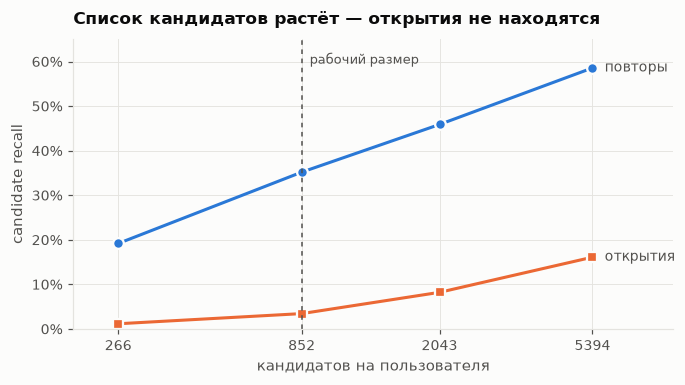

In [24]:
stats_te = build_global_stats(ev, WINDOWS["test"][0])      # ~3 секунды, отдельно от кеша сплитов

budget_rows = []
for cfg in [dict(n_recent=100, n_freq=60, n_cooc=60, n_pop=50, top_artists=20, tracks_per_artist=5),
            dict(n_recent=250, n_freq=150, n_cooc=200, n_pop=100, top_artists=60, tracks_per_artist=12),
            dict(n_recent=400, n_freq=250, n_cooc=350, n_pop=150, top_artists=120, tracks_per_artist=20),
            dict(n_recent=700, n_freq=400, n_cooc=600, n_pop=200, top_artists=250, tracks_per_artist=30)]:
    c = build_candidates(ev, USERS, stats_te, **cfg)
    row = {"кандидатов/юзер": round(c.height / c["user_idx"].n_unique())}
    for col, human in [(None, "всего"), ("is_repeat", "повторы"), ("is_new", "открытия")]:
        sub = truth_te if col is None else truth_te.filter(pl.col(col))
        row[human] = round(sub.join(c, on=["user_idx", "track_id"], how="semi").height / sub.height, 4)
    budget_rows.append(row)
    print(f"  {row['кандидатов/юзер']:>5} кандидатов -> recall всего {row['всего']:.1%}, "
          f"повторы {row['повторы']:.1%}, открытия {row['открытия']:.1%}")
budget_df = pl.DataFrame(budget_rows)

from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(figsize=(6.4, 3.6))
xb = budget_df["кандидатов/юзер"].to_numpy()
for col, color, marker in [("повторы", C_REPEAT, "o"), ("открытия", C_NEW, "s")]:
    yb = budget_df[col].to_numpy()
    ax.plot(xb, yb, marker=marker, color=color,
            markeredgecolor=SURFACE, markeredgewidth=1.5)
    ax.annotate(col, (xb[-1], yb[-1]), xytext=(8, 0), textcoords="offset points",
                color=INK_2, fontsize=9, va="center")
ax.axvline(852, color=INK_2, ls=(0, (3, 3)), lw=1)
ax.text(852, 0.62, "  рабочий размер", color=INK_2, fontsize=8.5, va="top")
ax.set_xscale("log"); ax.set_xlim(200, 9000); ax.set_ylim(0, 0.65)
ax.set_xticks([266, 852, 2043, 5394]); ax.set_xticklabels(["266", "852", "2043", "5394"])
ax.minorticks_off()
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_xlabel("кандидатов на пользователя"); ax.set_ylabel("candidate recall")
ax.set_title("Список кандидатов растёт — открытия не находятся")
plt.tight_layout(); save(fig, "02-recall-vs-budget"); plt.show()

Повторы находятся всё лучше, открытия — нет: их recall остаётся в районе пары процентов
даже когда кандидатов становится втрое больше. Причина не в настройках, а в природе задачи.
Открытие — это конкретный трек из полутора миллионов, и никакой топ популярного или
список соседей его не угадает. Даже сузив круг до артистов, которых юзер уже слушает
(а таких среди открытий 64%), мы всё равно ищем один трек среди сотен в их каталогах.

Отсюда важный вывод: **если хочется рекомендовать новое, узкое место — не ранжирование,
а кандидатогенерация.** Любой прирост, который мы дальше выжмем бустингом, будет приростом
на повторах просто потому, что открытий в кандидатах почти нет.
Держим это в голове, когда будем смотреть на красивые цифры.

### Главное число проекта: сколько в тестовом окне повторов

Прежде чем смотреть на модели — посмотрим на данные. Какая доля того, что юзер послушает
в тестовую неделю, это треки, которые он уже слушал раньше?

In [25]:
rep_share_pairs = truth_te["is_repeat"].mean()
rep_share_plays = (truth_te.filter(pl.col("is_repeat"))["label_plays"].sum()
                   / truth_te["label_plays"].sum())
head_share = truth_te["is_head"].mean()
print(f"доля повторов среди уникальных пар (юзер, трек) в тесте: {rep_share_pairs:.1%}")
print(f"доля повторов среди самих прослушиваний:                 {rep_share_plays:.1%}")
print(f"доля «головы» (топ-1% треков) среди тестовых позитивов:  {head_share:.1%}")

доля повторов среди уникальных пар (юзер, трек) в тесте: 69.2%
доля повторов среди самих прослушиваний:                 68.5%
доля «головы» (топ-1% треков) среди тестовых позитивов:  24.3%


In [26]:
BASELINES = {
    "Глобальная популярность": lambda X: X.with_columns(score=pl.col("pop").cast(pl.Float64)),
    "Личное повторение":       lambda X: X.with_columns(score=pl.col("u_track_cnt").cast(pl.Float64)),
    "Item-kNN":                lambda X: X.with_columns(score=pl.col("cooc_sim").cast(pl.Float64)),
}

nrel_te = n_rel_from(truth_te)
base_rows = []
for name, fn in BASELINES.items():
    m = evaluate(fn(Xte), nrel_te)
    base_rows.append({"подход": name, **{k: round(v, 4) for k, v in m.items() if k != "n_users"}})
    print(f"{name:26s} NDCG@10 {m['NDCG@10']:.4f}   MRR {m['MRR']:.4f}   R@50 {m['Recall@50']:.4f}")

Глобальная популярность    NDCG@10 0.0177   MRR 0.0645   R@50 0.0051
Личное повторение          NDCG@10 0.1412   MRR 0.2870   R@50 0.0463
Item-kNN                   NDCG@10 0.1410   MRR 0.2195   R@50 0.0457


### Проверка вменяемости

«Личное повторение» обязано заметно обходить «глобальную популярность». Если нет — сломан
сплит или кандидатогенерация, и дальше идти нельзя.

In [27]:
pop_ndcg = base_rows[0]["NDCG@10"]
rep_ndcg = base_rows[1]["NDCG@10"]
print(f"личное повторение {rep_ndcg:.4f}  vs  популярность {pop_ndcg:.4f}   "
      f"->  x{rep_ndcg/pop_ndcg:.1f}")
assert rep_ndcg > pop_ndcg * 1.5, "ПРОВЕРКА НЕ ПРОШЛА: подозрение на сломанный сплит"
print("проверка пройдена")

личное повторение 0.1412  vs  популярность 0.0177   ->  x8.0
проверка пройдена


---
## 6. Learning-to-rank: CatBoost YetiRank

`YetiRank` — ранжирующая функция потерь из CatBoost, родная для Яндекса конструкция.
Она **попарная**: модель учится не предсказывать метку каждого кандидата по отдельности,
а отвечать на вопрос «кто из этих двоих должен стоять выше». Для ранжирования это
естественнее — нам ведь важен порядок, а не абсолютные числа.

Отсюда же берётся `group_id` — это указание, в каких пределах модели разрешено строить
такие пары. Ставим группировку по пользователю: сравнивать имеет смысл кандидатов внутри
одной выдачи, а сопоставлять трек одного человека с треком другого бессмысленно,
они никогда не окажутся в одном списке.

Число итераций подбираем по валидационному окну, тест для этого не трогаем.

In [28]:
def make_pool(df, features, label_col="label"):
    d = df.sort("user_idx")
    return Pool(data=d.select(features).to_numpy().astype(np.float32),
                label=d[label_col].to_numpy().astype(float),
                group_id=d["user_idx"].to_numpy(), feature_names=list(features))

def fit_ranker(train_df, features, valid_df=None, label_col="label",
               iterations=800, lr=0.06, depth=6, seed=SEED, verbose=0):
    m = CatBoostRanker(loss_function="YetiRank", iterations=iterations, learning_rate=lr,
                       depth=depth, random_seed=seed, verbose=verbose, thread_count=N_THREADS,
                       allow_writing_files=False,
                       early_stopping_rounds=60 if valid_df is not None else None,
                       eval_metric="NDCG:top=10;type=Exp")
    # На валидации метки ВСЕГДА настоящие бинарные, даже когда обучаемся на IPW-релевантности:
    # ранняя остановка должна смотреть на ту метрику, которую мы в итоге и меряем.
    m.fit(make_pool(train_df, features, label_col),
          eval_set=make_pool(valid_df, features) if valid_df is not None else None)
    return m

def score_model(model, df, features):
    d = df.sort("user_idx")
    return d.with_columns(score=pl.Series("score", model.predict(
        d.select(features).to_numpy().astype(np.float32))))

t0 = time.time()
model = fit_ranker(Xtr, FEATURES, valid_df=Xva)
print(f"обучение заняло {time.time()-t0:.0f}s, лучшая итерация {model.get_best_iteration()}")

m_cb = evaluate(score_model(model, Xte, FEATURES), nrel_te)
print(f"\nCatBoost YetiRank: NDCG@10 {m_cb['NDCG@10']:.4f}   MRR {m_cb['MRR']:.4f}   "
      f"R@50 {m_cb['Recall@50']:.4f}")
print(f"прирост к лучшему бейзлайну: {m_cb['NDCG@10']/rep_ndcg - 1:+.1%}")

обучение заняло 27s, лучшая итерация 83

CatBoost YetiRank: NDCG@10 0.3299   MRR 0.4703   R@50 0.1128
прирост к лучшему бейзлайну: +133.7%


### Важность признаков

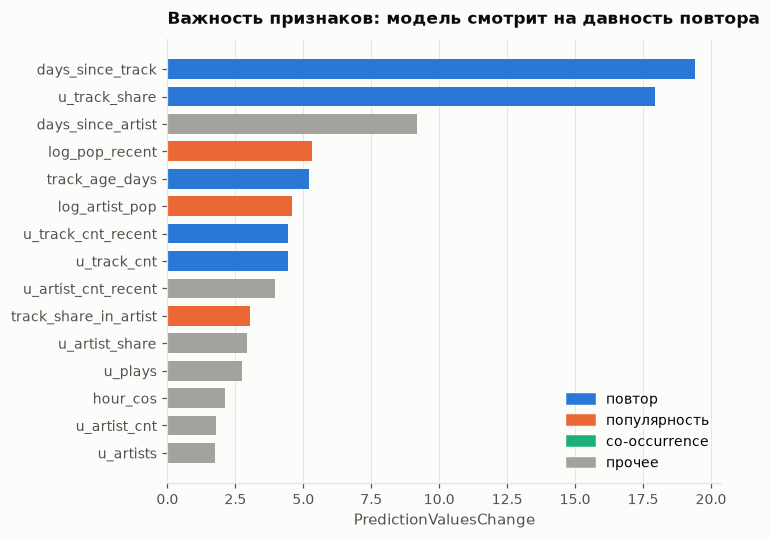

признак,важность
str,f64
"""days_since_track""",19.411745
"""u_track_share""",17.938491
"""days_since_artist""",9.178511
"""log_pop_recent""",5.306552
"""track_age_days""",5.201405
"""log_artist_pop""",4.579604
"""u_track_cnt_recent""",4.449217
"""u_track_cnt""",4.429226
"""u_artist_cnt_recent""",3.95809


In [29]:
imp = (pl.DataFrame({"признак": FEATURES,
                     "важность": model.get_feature_importance(type="PredictionValuesChange")})
         .sort("важность", descending=True))

# группы признаков — понадобятся и дальше, при разборе смещений
rep_feats = ["u_track_cnt", "u_track_cnt_recent", "u_track_share", "is_repeat",
             "days_since_track", "track_age_days", "from_recent", "from_freq"]
pop_feats = ["log_pop", "log_pop_recent", "log_pop_users", "log_artist_pop", "from_pop",
             "track_share_in_artist"]
cooc_feats = ["cooc_sim", "cooc_cnt", "log_cooc", "from_cooc"]
GROUPS = [("повтор", rep_feats, C_REPEAT), ("популярность", pop_feats, ORANGE),
          ("co-occurrence", cooc_feats, AQUA)]
group_of = {f: (g, c) for g, fs, c in GROUPS for f in fs}

fig, ax = plt.subplots(figsize=(6.8, 5))
top = imp.head(15).reverse()
colors = [group_of.get(f, ("прочее", GRAY))[1] for f in top["признак"]]
ax.barh(top["признак"], top["важность"], color=colors, height=0.72)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=g) for g, _, c in GROUPS + [("прочее", [], GRAY)]],
          loc="lower right")
ax.grid(axis="y", visible=False)
ax.set_xlabel("PredictionValuesChange")
ax.set_title("Важность признаков: модель смотрит на давность повтора")
plt.tight_layout(); save(fig, "05-feature-importance"); plt.show()
imp.head(12)

---
## 7. Разбор смещений

Это сердце проекта. Общая метрика выросла — но откуда именно взялся прирост?

Режем метрику двумя способами:

* **голова против хвоста** — популярные треки (топ-1% по обучающему периоду) против всего остального;
* **повторы против открытий** — треки, которые юзер уже слушал, против новых для него.

У среза «открытия» считаем два числа, и они отвечают на разные вопросы:

* **в общей выдаче** — оставляем ранжирование как есть, релевантными считаем только новые треки.
  Это то, что реально видит пользователь: если топ-10 забит повторами, открытий он не увидит.
* **только среди новых** — выкидываем из выдачи все знакомые треки и ранжируем то, что осталось.
  Это честный тест способности модели: даже когда повторам не дают занимать места,
  умеет ли она отличить хорошее новое от плохого нового?

Первое число показывает продуктовую проблему, второе — техническую.

In [30]:
def full_report(scored, truth, seed=SEED):
    slices = [("всего", None, False), ("повторы", "is_repeat", False),
              ("открытия (в общей выдаче)", "is_new", False),
              ("открытия (только среди новых)", "is_new", True),
              ("голова", "is_head", False), ("хвост", "is_tail", False)]
    out = {}
    for human, col, restr in slices:
        mask = None if col is None else col
        out[human] = evaluate(scored, n_rel_from(truth, mask), slice_col=col,
                              restrict=restr, seed=seed)
    return out

def report_table(reports, metric="NDCG@10"):
    rows = []
    for model_name, rep in reports.items():
        rows.append({"подход": model_name, **{k: round(v[metric], 4) for k, v in rep.items()}})
    return pl.DataFrame(rows)

REPORTS = {}
for name, fn in BASELINES.items():
    REPORTS[name] = full_report(fn(Xte), truth_te)
REPORTS["CatBoost YetiRank"] = full_report(score_model(model, Xte, FEATURES), truth_te)

print("NDCG@10 по срезам:")
report_table(REPORTS)

NDCG@10 по срезам:


подход,всего,повторы,открытия (в общей выдаче),открытия (только среди новых),голова,хвост
str,f64,f64,f64,f64,f64,f64
"""Глобальная популярность""",0.0177,0.0173,0.0013,0.003,0.0199,0.0
"""Личное повторение""",0.1412,0.1505,0.0,0.0023,0.0816,0.0729
"""Item-kNN""",0.141,0.1459,0.0034,0.0179,0.083,0.0663
"""CatBoost YetiRank""",0.3299,0.3523,0.0,0.0256,0.1771,0.1807


### Ноль на открытиях — это буквально ноль

В таблице выше NDCG@10 на открытиях у CatBoost равен 0.0000. Круглые нули в метриках
обычно означают баг, поэтому проверим отдельно: посмотрим, из чего состоит топ-10
и на каких позициях вообще оказываются открытия.

In [31]:
ranked = (score_model(model, Xte, FEATURES)
          .sort(["user_idx", "score"], descending=[False, True])
          .with_columns(pos=pl.int_range(pl.len()).over("user_idx") + 1))
top10 = ranked.filter(pl.col("pos") <= 10)
print(f"позиций в топ-10 суммарно по всем юзерам: {top10.height:,}")
print(f"   из них повторы:  {top10['is_repeat'].mean():>6.1%}")
print(f"   из них открытия: {(top10['is_repeat'] == 0).mean():>6.1%}")

pos_new = ranked.filter((pl.col("label") > 0) & pl.col("is_new"))["pos"]
print(f"\nугаданных открытий в кандидатах: {pos_new.len()}")
print(f"позиции, на которых они стоят: минимум {pos_new.min()}, "
      f"медиана {pos_new.median():.0f}, максимум {pos_new.max()}")
print(f"   попало в топ-10: {(pos_new <= 10).sum()}")
print(f"   попало в топ-50: {(pos_new <= 50).sum()}")

позиций в топ-10 суммарно по всем юзерам: 3,000
   из них повторы:  100.0%
   из них открытия:   0.0%

угаданных открытий в кандидатах: 343
позиции, на которых они стоят: минимум 144, медиана 551, максимум 963
   попало в топ-10: 0
   попало в топ-50: 0


Бага нет. Топ-10 у **всех** пользователей состоит из повторов на 100%, а самое высоко
стоящее открытие во всей выборке — на позиции в несколько сотен. В топ-50 не попадает
ни одно.

Так выглядят «рекомендации, которые не слышат», если посмотреть на них числами:
система не то чтобы плохо предлагает новое — она не предлагает его вообще.

### Насколько модель опирается на популярность

In [32]:
tot = imp["важность"].sum()
share = lambda fs: imp.filter(pl.col("признак").is_in(fs))["важность"].sum() / tot
print(f"суммарная важность признаков популярности: {share(pop_feats):.1%}")
print(f"суммарная важность признаков повтора:      {share(rep_feats):.1%}")
print(f"суммарная важность co-occurrence:          {share(cooc_feats):.1%}")

суммарная важность признаков популярности: 15.6%
суммарная важность признаков повтора:      52.0%
суммарная важность co-occurrence:          2.9%


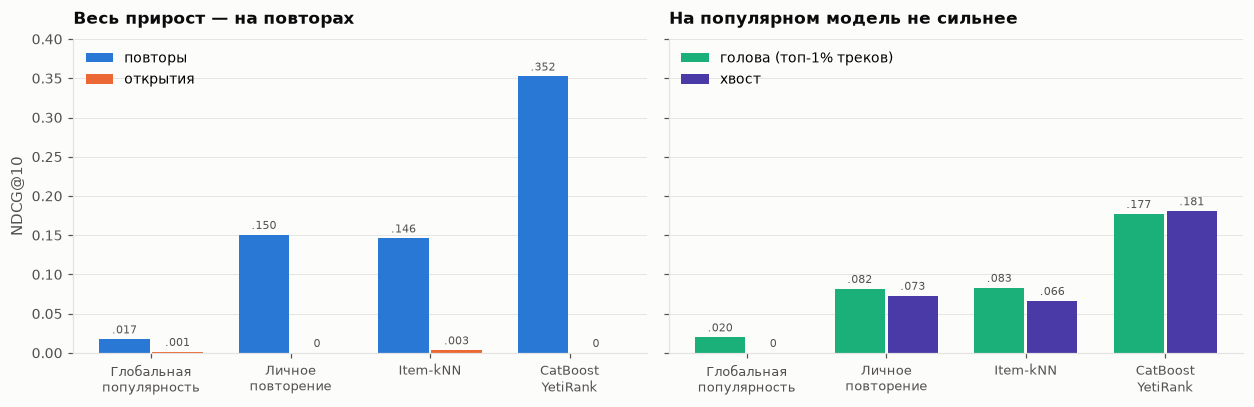

In [33]:
def grouped_bars(ax, names, slices, title):
    """Столбики по подходам, два среза рядом; подписи значений — прямо на столбиках."""
    x, w = np.arange(len(names)), 0.36
    for i, (sl, label, color) in enumerate(slices):
        vals = [REPORTS[n][sl]["NDCG@10"] for n in names]
        bars = ax.bar(x + (i - 0.5) * (w + 0.02), vals, width=w, label=label, color=color)
        for b_, v in zip(bars, vals):
            ax.text(b_.get_x() + b_.get_width() / 2, v + 0.004, f"{v:.3f}".lstrip("0") if v else "0",
                    ha="center", va="bottom", fontsize=7.5, color=INK_2)
    ax.set_xticks(x); ax.set_xticklabels([n.replace(" ", "\n", 1) for n in names], fontsize=8.5)
    ax.grid(axis="x", visible=False)
    ax.set_title(title); ax.legend(loc="upper left")


fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8), sharey=True)
names = list(REPORTS.keys())
grouped_bars(ax[0], names, [("повторы", "повторы", C_REPEAT),
                            ("открытия (в общей выдаче)", "открытия", C_NEW)],
             "Весь прирост — на повторах")
grouped_bars(ax[1], names, [("голова", "голова (топ-1% треков)", C_HEAD),
                            ("хвост", "хвост", C_TAIL)],
             "На популярном модель не сильнее")
ax[0].set_ylabel("NDCG@10"); ax[0].set_ylim(0, 0.4)
plt.tight_layout(); save(fig, "03-repeats-vs-discoveries"); plt.show()

---
## 8. Дебайас

### Идея

Единица в обучающей выборке значит «пользователь послушал этот трек». Но чтобы послушать,
он должен был сначала **на трек наткнуться**. А вероятность наткнуться сильно зависит
от популярности: раскрученный трек лезет отовсюду, а хороший, но безвестный человек
может не встретить никогда.

Значит, наши единицы — не чистые предпочтения, а предпочтения, умноженные на
«попадаемость на глаза». Модель, обучаясь на них, выучит в том числе и эту попадаемость.

**Propensity** (можно перевести как «склонность попасть в лог») — это как раз вероятность
того, что событие вообще окажется в наших данных. **IPW** — inverse propensity weighting,
«перевзвешивание обратно склонности»: каждому примеру дают вес, обратный вероятности
его наблюдения. Логика такая: если событие имело один шанс из ста попасть в логи,
а всё-таки попало, оно должно весить как сто обычных — оно представляет собой
те девяносто девять похожих, которых мы не увидели.

Настоящую propensity знать неоткуда: для этого нужны логи показов, а у нас их нет
(об этом было в самом начале). Поэтому берём её грубое приближение через популярность.

**Обозначения.** Для обучающего примера с номером $i$:

* $\mathrm{pop}_i$ — популярность трека из этого примера: сколько всего раз его слушали
  за обучающий период;
* $p_i$ — предполагаемая propensity, то есть насколько легко было на этот трек наткнуться;
* $w_i$ — вес, который мы этому примеру дадим;
* $\eta$ (греческая «эта») — **ручка силы поправки**, число от 0 до 1, которое подбирается на валидации.

Сама поправка:

$$p_i \propto \mathrm{pop}_i^{\eta}, \qquad w_i = \frac{1}{p_i} \propto \mathrm{pop}_i^{-\eta}$$

Значок $\propto$ читается «пропорционально»: абсолютный масштаб неважен, важны отношения
между примерами. Читается всё это так: чем популярнее трек, тем легче было на него
наткнуться, тем меньший вес он получает.

Роль $\eta$:

* $\eta = 0$ — поправки нет вообще ($\mathrm{pop}^0 = 1$, все веса равны единице);
* $\eta = 1$ — вес обратно пропорционален популярности: трек, который слушали в десять раз
  чаще, весит в десять раз меньше;
* промежуточные значения — промежуточная сила.

$\eta$ подбираем по валидационному окну, тест для этого не трогаем.

**Честная оговорка.** Это поправка в духе IPW на **экспозицию** (то есть на то, насколько
трек вообще попадался людям на глаза), но не полноценная **counterfactual-оценка** —
так называют попытку ответить на вопрос «а что было бы, если бы мы показали другую выдачу»
по одним лишь историческим логам, без запуска эксперимента.

Чтобы посчитать её честно, нужно знать **логирующую политику**: какую выдачу построила
работавшая тогда система и с какой вероятностью она показала каждый вариант. Зная это,
можно пересчитать логи под новую модель. У нас этих данных нет вообще — есть только факт
прослушивания. Мы поправляем на наблюдаемую популярность и надеемся, что она хоть как-то
связана с экспозицией; проверить это предположение на этих данных нечем.

### Как подать веса в YetiRank: маленькое расследование

Очевидный способ — передать `weight` в `Pool`. Но CatBoost на это отвечает предупреждением:

> `Pairwise losses don't support object weights.`

YetiRank — попарный лосс, и веса он схлопывает на уровень группы. Предупреждение легко
проглядеть (оно уходит в stderr), а эксперимент при этом молча превратится в пустышку:
веса переданы, а эффекта почти нет.

Проверяем экспериментом. Берём одни и те же веса и **перемешиваем их внутри каждой группы** —
групповые суммы не меняются, меняется только распределение по объектам. Если лосс
по-настоящему использует по-объектные веса, результат обязан измениться.

In [34]:
_rng = np.random.default_rng(0)
_n = 1200
_g = np.repeat(np.arange(60), 20)
_X = _rng.normal(size=(_n, 4))
_y = (_X[:, 0] + _rng.normal(scale=.5, size=_n) > 0).astype(float)
_w = _rng.uniform(0.1, 3.0, size=_n)
_wperm = _w.copy()
for _gi in np.unique(_g):                       # перестановка ВНУТРИ группы
    _m = _g == _gi
    _v = _wperm[_m]; _rng.shuffle(_v); _wperm[_m] = _v

def _fit_w(loss, w):
    mm = CatBoostRanker(loss_function=loss, iterations=60, verbose=0,
                        thread_count=1, random_seed=0,          # 1 поток -> полный детерминизм
                        allow_writing_files=False)
    mm.fit(Pool(_X, label=_y, group_id=_g, weight=w))
    return mm.predict(_X)

print(f"{'лосс':22s} {'контроль':>12s} {'перестановка':>14s}")
for _loss in ["YetiRank", "QuerySoftMax", "LambdaMart"]:
    _ctrl = float(np.abs(_fit_w(_loss, _w) - _fit_w(_loss, _w)).max())
    _perm = float(np.abs(_fit_w(_loss, _w) - _fit_w(_loss, _wperm)).max())
    print(f"{_loss:22s} {_ctrl:12.6f} {_perm:14.6f}")
print("\nконтроль ровно 0 -> недетерминизма нет, эффект настоящий.")
print("но у YetiRank он на 2-3 порядка слабее, чем у listwise-лоссов: как механизм дебайаса не годится.")

лосс                       контроль   перестановка


Pairwise losses don't support object weights.
Pairwise losses don't support object weights.


Pairwise losses don't support object weights.
Pairwise losses don't support object weights.


YetiRank                   0.000000       0.000993
QuerySoftMax               0.000000       0.149208


LambdaMart                 0.000000       0.481239

контроль ровно 0 -> недетерминизма нет, эффект настоящий.
но у YetiRank он на 2-3 порядка слабее, чем у listwise-лоссов: как механизм дебайаса не годится.


### Обходной путь: IPW через градуированную релевантность

YetiRank умеет работать с **градуированной** релевантностью: метка не обязана быть 0 или 1,
она может быть любым числом, и чем оно больше, тем «правильнее» ответ. Значит, вес можно
занести не сбоку, а прямо в метку:

$$rel_i = w_i \cdot y_i = \mathrm{pop}_i^{-\eta} \cdot y_i$$

где $y_i$ — исходная двоичная метка (1, если пользователь послушал трек в окне меток,
иначе 0), а $w_i$ и $\eta$ — те же, что в формуле выше.

Что при этом происходит. У негативов $y_i = 0$, так что они остаются нулями при любом
$\eta$ — их поправка не трогает. А позитивы расслаиваются: тот, что с популярным треком,
получает релевантность заметно меньше единицы, тот, что с хвостовым, — больше.
YetiRank строит пары «этот выше того» и взвешивает их по разнице релевантностей,
так что редкие позитивы начинают тянуть сильнее популярных. Тот самый эффект,
которого добивались весами.

Веса нормируем так, чтобы среднее по позитивам осталось равным единице. Иначе вместе
с $\eta$ менялся бы и общий масштаб релевантностей, и было бы непонятно, что именно
повлияло на результат — перераспределение между треками или просто другие числа на входе.

In [35]:
def add_ipw_label(df, eta, pop_col="pop", label_col="label"):
    d = df.with_columns(_w=(pl.col(pop_col).cast(pl.Float64) + 1.0).pow(-eta))
    mean_w = d.filter(pl.col(label_col) > 0)["_w"].mean()
    return d.with_columns(label_ipw=(pl.col("_w") / mean_w) * pl.col(label_col)).drop("_w")

### Подбор η на валидации

Тест не трогаем. Смотрим на две вещи сразу: общий NDCG@10 и NDCG@10 на открытиях —
именно ради второго всё и затевалось.

  eta=0.0   общий 0.3598   открытия 0.0264


  eta=0.15  общий 0.3399   открытия 0.0130


  eta=0.3   общий 0.2953   открытия 0.0113


  eta=0.5   общий 0.2304   открытия 0.0031


  eta=0.75  общий 0.1721   открытия 0.0031


  eta=1.0   общий 0.1359   открытия 0.0027


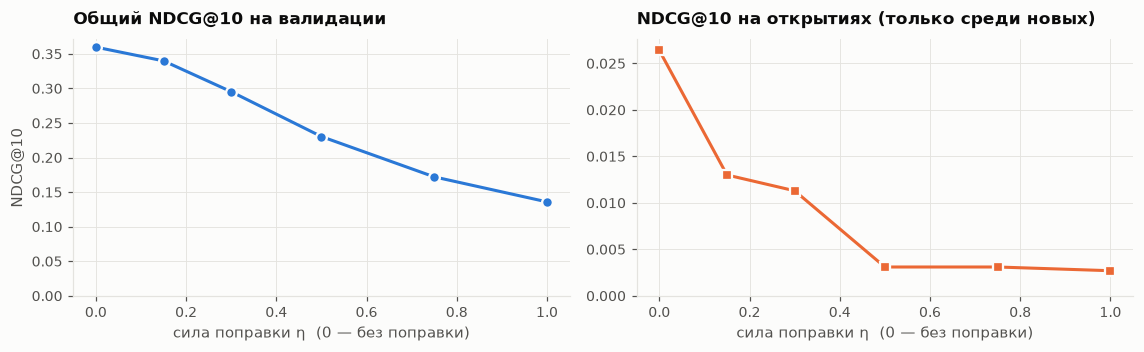


валидация выбирает η = 0


In [36]:
ETAS = [0.0, 0.15, 0.3, 0.5, 0.75, 1.0]
nrel_va = n_rel_from(truth_va)
nrel_va_new = n_rel_from(truth_va, "is_new")

sweep = []
for eta in ETAS:
    mdl = fit_ranker(add_ipw_label(Xtr, eta), FEATURES, label_col="label_ipw",
                     iterations=model.get_best_iteration() + 1)
    sc = score_model(mdl, Xva, FEATURES)
    a = evaluate(sc, nrel_va)
    c = evaluate(sc, nrel_va_new, slice_col="is_new", restrict=True)
    sweep.append({"eta": eta, "NDCG@10": round(a["NDCG@10"], 4),
                  "открытия (среди новых)": round(c["NDCG@10"], 4)})
    print(f"  eta={eta:<5} общий {a['NDCG@10']:.4f}   открытия {c['NDCG@10']:.4f}")
sweep_df = pl.DataFrame(sweep)

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.3))
for a, col, color, marker, title in [
        (ax[0], "NDCG@10", BLUE, "o", "Общий NDCG@10 на валидации"),
        (ax[1], "открытия (среди новых)", C_NEW, "s", "NDCG@10 на открытиях (только среди новых)")]:
    a.plot(sweep_df["eta"], sweep_df[col], marker=marker, color=color,
           markeredgecolor=SURFACE, markeredgewidth=1.5)
    a.set_xlabel("сила поправки η  (0 — без поправки)"); a.set_title(title)
    a.set_ylim(0, None)
ax[0].set_ylabel("NDCG@10")
plt.tight_layout(); save(fig, "04-eta-sweep"); plt.show()

BEST_ETA = float(sweep_df.sort(["открытия (среди новых)", "NDCG@10"], descending=True)["eta"][0])
print(f"\nвалидация выбирает η = {BEST_ETA:g}")

### Поправка не работает. Разбираемся, почему

Обе кривые падают монотонно. Валидация выбирает **η = 0**, то есть «не делать ничего»:
любая поправка на популярность делает хуже и общую метрику, и метрику на открытиях.

Подкручивать тут нечего — это и есть результат. Но результат надо объяснить, иначе он
выглядит как «код не заработал». Три замера, которые вместе всё объясняют.

In [37]:
print("1) Опирается ли модель на популярность вообще?")
print(f"   суммарная важность признаков популярности: {share(pop_feats):.1%}")
print(f"   суммарная важность признаков повтора:      {share(rep_feats):.1%}")

print("\n2) Работает ли модель лучше на популярном?")
cb = REPORTS["CatBoost YetiRank"]
print(f"   NDCG@10 на голове {cb['голова']['NDCG@10']:.4f}   на хвосте {cb['хвост']['NDCG@10']:.4f}")
print("   -> преимущества на голове нет, то есть чинить нечего")

print("\n3) А какие открытия мы вообще умеем доставать?")
new_in = Xte.filter((pl.col("label") > 0) & pl.col("is_new"))
new_all = truth_te.filter(pl.col("is_new"))
print(f"   открытий в тесте {new_all.height:,}, попало в кандидатов {new_in.height:,} "
      f"({new_in.height/new_all.height:.1%})")
print("   откуда они пришли:")
for c in ["from_artist", "from_cooc", "from_pop"]:
    print(f"      {c:12s} {new_in[c].mean():>6.1%}")
print(f"   доля «головы» среди ДОСТИЖИМЫХ открытий: {new_in['is_head'].mean():.1%}")
print(f"   доля «головы» среди ВСЕХ открытий:       {new_all['is_head'].mean():.1%}")

1) Опирается ли модель на популярность вообще?
   суммарная важность признаков популярности: 15.6%
   суммарная важность признаков повтора:      52.0%

2) Работает ли модель лучше на популярном?
   NDCG@10 на голове 0.1771   на хвосте 0.1807
   -> преимущества на голове нет, то есть чинить нечего

3) А какие открытия мы вообще умеем доставать?
   открытий в тесте 9,965, попало в кандидатов 343 (3.4%)
   откуда они пришли:
      from_artist   60.6%
      from_cooc     34.7%
      from_pop      14.9%
   доля «головы» среди ДОСТИЖИМЫХ открытий: 55.4%
   доля «головы» среди ВСЕХ открытий:       15.9%


Картина складывается.

**Popularity bias, который мы собирались лечить, здесь просто отсутствует.** Модель берёт
больше половины важности из признаков повтора и лишь шестую часть — из популярности,
а на голове работает не лучше, чем на хвосте. Лечить нечего.

**А поправка при этом активно вредит.** Открытия, до которых воронка вообще дотягивается, —
это популярные треки знакомых артистов: среди достижимых открытий «головы» в три с лишним
раза больше, чем среди открытий вообще. Штрафуя популярность, мы топим ровно тот
единственный тип открытий, который умеем находить. Отсюда и монотонное падение.

### Вторая попытка: поправка на то смещение, которое здесь действительно есть

Раз главное смещение — repeat, а не popularity, логично перевзвесить по нему.
Обоснование то же самое, что у IPW: вероятность «наблюдать» позитив резко выше для трека,
который у юзера уже в библиотеке — он всегда под рукой, его не надо находить.
Значит, повторам надо дать вес меньше единицы. Роль ручки силы играет $\rho$
(греческая «ро»): при $\rho = 1$ поправки нет, при $\rho = 0$ повторы полностью
выключаются из обучения, промежуточные значения — промежуточная сила.

$$rel_i = \begin{cases} 1, & \text{трек новый для юзера} \\ \rho, & \text{трек уже слушали} \end{cases}$$

In [38]:
rep_sweep = []
for rho in [1.0, 0.5, 0.25, 0.1, 0.03]:
    d = Xtr.with_columns(label_rep=pl.when(pl.col("label") == 0).then(0.0)
                                     .when(pl.col("is_new")).then(1.0).otherwise(rho))
    mdl = fit_ranker(d, FEATURES, label_col="label_rep",
                     iterations=model.get_best_iteration() + 1)
    sc = score_model(mdl, Xva, FEATURES)
    a = evaluate(sc, nrel_va)
    c = evaluate(sc, nrel_va_new, slice_col="is_new", restrict=True)
    rep_sweep.append({"вес повтора ρ": rho, "NDCG@10": round(a["NDCG@10"], 4),
                      "открытия (среди новых)": round(c["NDCG@10"], 4)})
    print(f"  ρ={rho:<5} общий {a['NDCG@10']:.4f}   открытия {c['NDCG@10']:.4f}")
pl.DataFrame(rep_sweep)

  ρ=1.0   общий 0.3598   открытия 0.0264


  ρ=0.5   общий 0.3582   открытия 0.0201


  ρ=0.25  общий 0.3554   открытия 0.0187


  ρ=0.1   общий 0.3061   открытия 0.0147


  ρ=0.03  общий 0.0991   открытия 0.0139


вес повтора ρ,NDCG@10,открытия (среди новых)
f64,f64,f64
1.0,0.3598,0.0264
0.5,0.3582,0.0201
0.25,0.3554,0.0187
0.1,0.3061,0.0147
0.03,0.0991,0.0139


### Насколько эти различия вообще отличимы от шума

Прежде чем делать вывод из падения 0.026 → 0.019, надо понять цену деления. Открытий,
попавших в кандидатов, всего несколько сотен на всю выборку — это примерно полтора
позитива на пользователя. Оценим разброс бутстрапом.

In [39]:
sc_base = score_model(model, Xva, FEATURES)
m, lo, hi = bootstrap_ci(sc_base, truth_va, "is_new", restrict=True, n_boot=400)
print(f"NDCG@10 на открытиях (валидация): {m:.4f}, 95% интервал [{lo:.4f}, {hi:.4f}]")
print(f"ширина интервала: {hi-lo:.4f}")
print(f"разброс по всему свипу ρ: {max(r['открытия (среди новых)'] for r in rep_sweep) - min(r['открытия (среди новых)'] for r in rep_sweep):.4f}")
print("\n-> весь свип укладывается внутрь доверительного интервала одной точки.")
print("   Утверждать по нему что-либо про открытия нельзя, и это тоже результат.")

NDCG@10 на открытиях (валидация): 0.0264, 95% интервал [0.0138, 0.0400]
ширина интервала: 0.0262
разброс по всему свипу ρ: 0.0125

-> весь свип укладывается внутрь доверительного интервала одной точки.
   Утверждать по нему что-либо про открытия нельзя, и это тоже результат.


### Вывод раздела: лоссом не чинится то, что сломано в воронке

Ни поправка на популярность, ни поправка на повторность не улучшают открытия.
Обе ухудшают общую метрику, обе оставляют метрику на открытиях внутри шума,
и обе на валидации проигрывают варианту «ничего не делать».

Причина не в том, что перевзвешивание — плохая идея. Причина в том, что **до ранжирования
дело не доходит**: в списке кандидатов лежит 3.4% открытий. Никакие веса в лоссе
не поднимут наверх то, чего в списке нет. Всё, что делает перевзвешивание, —
портит обучение на тех 96.6% задачи, которые состоят из повторов.

Это, пожалуй, главный практический вывод проекта. Когда метрика на срезе плохая, первым делом
надо смотреть не на лосс, а на recall кандидатогенерации на этом срезе. Задумывалось,
что центральной частью работы будет дебайас; на этих данных центральной оказалась воронка.

В итоговой таблице — обе строки: модель с выбранной на валидации поправкой
(η = 0, то есть та же самая) и принудительный η = 0.5 — чтобы было видно, чего стоит
«дебайас ради дебайаса».

In [40]:
model_ipw = fit_ranker(add_ipw_label(Xtr, BEST_ETA), FEATURES, valid_df=Xva, label_col="label_ipw")
REPORTS[f"CatBoost + дебайас (η={BEST_ETA:g}, выбран на валидации)"] = full_report(
    score_model(model_ipw, Xte, FEATURES), truth_te)

model_forced = fit_ranker(add_ipw_label(Xtr, 0.5), FEATURES, valid_df=Xva, label_col="label_ipw")
REPORTS["CatBoost + дебайас (η=0.5, принудительно)"] = full_report(
    score_model(model_forced, Xte, FEATURES), truth_te)
print("обе версии обучены")

обе версии обучены


---
## 9. Итоги, разбор ошибок и выводы

### Итоговая таблица

In [41]:
def final_table(reports):
    rows = []
    for name, rep in reports.items():
        rows.append({
            "подход": name,
            "NDCG@10": round(rep["всего"]["NDCG@10"], 4),
            "NDCG@10 повторы": round(rep["повторы"]["NDCG@10"], 4),
            "NDCG@10 открытия": round(rep["открытия (в общей выдаче)"]["NDCG@10"], 4),
            "открытия (среди новых)": round(rep["открытия (только среди новых)"]["NDCG@10"], 4),
            "голова": round(rep["голова"]["NDCG@10"], 4),
            "хвост": round(rep["хвост"]["NDCG@10"], 4),
            "MRR": round(rep["всего"]["MRR"], 4),
            "Recall@50": round(rep["всего"]["Recall@50"], 4),
        })
    return pl.DataFrame(rows)

FINAL = final_table(REPORTS)
FINAL.write_parquet(CACHE / "final_table.parquet")
FINAL

подход,NDCG@10,NDCG@10 повторы,NDCG@10 открытия,открытия (среди новых),голова,хвост,MRR,Recall@50
str,f64,f64,f64,f64,f64,f64,f64,f64
"""Глобальная популярность""",0.0177,0.0173,0.0013,0.003,0.0199,0.0,0.0645,0.0051
"""Личное повторение""",0.1412,0.1505,0.0,0.0023,0.0816,0.0729,0.287,0.0463
"""Item-kNN""",0.141,0.1459,0.0034,0.0179,0.083,0.0663,0.2195,0.0457
"""CatBoost YetiRank""",0.3299,0.3523,0.0,0.0256,0.1771,0.1807,0.4703,0.1128
"""CatBoost + дебайас (η=0, выбра…",0.3299,0.3523,0.0,0.0256,0.1771,0.1807,0.4703,0.1128
"""CatBoost + дебайас (η=0.5, при…",0.2208,0.2348,0.0,0.0024,0.0004,0.2224,0.3683,0.0816


Отдельно стоит посмотреть на последнюю строку — ту, где η = 0.5 включён принудительно.
Она снимает единственное оставшееся сомнение: а не сломан ли сам дебайас?

Не сломан. Он делает именно то, для чего предназначен: **метрика на голове падает
с 0.177 практически до нуля, а на хвосте растёт с 0.181 до 0.222.** Перевзвешивание
честно перекладывает вес с популярного на редкое, механизм работает.

Просто на этих данных такой обмен никому не нужен. Мы отдаём половину общей метрики
за перераспределение внутри повторов — а открытия, ради которых всё затевалось,
как были нулём, так нулём и остались. Инструмент исправен, диагноз был неверный.

### Bootstrap: насколько этим числам вообще можно верить

300 юзеров — не так много. Прежде чем делать выводы из разницы в третьем знаке,
полезно посмотреть на доверительные интервалы. Бутстрап по пользователям
(перевыбираем юзеров с возвращением, метрику пересчитываем).

In [42]:
for nm, sc in [("Личное повторение", BASELINES["Личное повторение"](Xte)),
               ("CatBoost YetiRank", score_model(model, Xte, FEATURES)),
               (f"CatBoost + дебайас", score_model(model_ipw, Xte, FEATURES))]:
    m, lo, hi = bootstrap_ci(sc, truth_te)
    mn, lon, hin = bootstrap_ci(sc, truth_te, "is_new", restrict=True)
    print(f"{nm:24s} всего {m:.4f} [{lo:.4f}, {hi:.4f}]   "
          f"открытия {mn:.4f} [{lon:.4f}, {hin:.4f}]")

Личное повторение        всего 0.1412 [0.1108, 0.1680]   открытия 0.0023 [0.0008, 0.0042]
CatBoost YetiRank        всего 0.3299 [0.2861, 0.3782]   открытия 0.0256 [0.0130, 0.0421]
CatBoost + дебайас       всего 0.3299 [0.2861, 0.3782]   открытия 0.0256 [0.0130, 0.0421]


### Разбор ошибок руками

Агрегированная метрика говорит «стало лучше», но не говорит «почему». Посмотрим на конкретные
выдачи: что модель поставила в топ-10 и что юзер послушал на самом деле.

In [43]:
sc_cb = score_model(model, Xte, FEATURES)
names = tracks.select("track_id", "artist", "track")

def show_user(uid, scored, k=10):
    d = (scored.filter(pl.col("user_idx") == uid).join(names, on="track_id")
         .sort("score", descending=True).head(k)
         .select("artist", "track", "score", "label", "is_repeat", "pop"))
    return d

# Случайный юзер из тех, у кого в тестовом окне хотя бы 5 открытий. sorted здесь нужен
# по той же причине, что и в подвыборке: group_by не гарантирует порядок строк.
_rng2 = np.random.default_rng(7)
cands = sorted(truth_te.filter(pl.col("is_new")).group_by("user_idx").agg(n=pl.len())
               .filter(pl.col("n") >= 5)["user_idx"].to_list())
uid = int(cands[_rng2.integers(0, len(cands))])
print(f"юзер {uid}: в тестовом окне послушал {int(truth_te.filter(pl.col('user_idx')==uid).height)} "
      f"разных треков, из них открытий {int(truth_te.filter((pl.col('user_idx')==uid) & pl.col('is_new')).height)}")
print("\nтоп-10 от CatBoost:")
show_user(uid, sc_cb)

юзер 939: в тестовом окне послушал 15 разных треков, из них открытий 7

топ-10 от CatBoost:


artist,track,score,label,is_repeat,pop
str,str,f64,i8,i8,u32
"""Stephan Hinz""","""Plattenleger 220309 Pt 1""",2.177068,0,1,5
"""Band Of Horses""","""Is There A Ghost""",1.880255,0,1,615
"""Death Cab For Cutie""","""Summer Skin""",1.843096,0,1,2090
"""Booka Shade""","""Outskirts""",1.838503,0,1,56
"""Death Cab For Cutie""","""Different Names For The Same T…",1.836567,0,1,1699
"""Death Cab For Cutie""","""I Will Follow You Into The Dar…",1.78331,0,1,2917
"""Death Cab For Cutie""","""Marching Bands Of Manhattan""",1.763416,0,1,1947
"""Band Of Horses""","""No One'S Gonna Love You""",1.742738,0,1,669
"""Booka Shade""","""Charlotte""",1.708628,0,1,80


In [44]:
print("а вот что юзер реально послушал впервые (открытия), и на каком месте это оказалось у модели:")
new_truth = truth_te.filter((pl.col("user_idx") == uid) & pl.col("is_new"))
ranked = (sc_cb.filter(pl.col("user_idx") == uid).sort("score", descending=True)
          .with_row_index("позиция").with_columns(pl.col("позиция") + 1))
(new_truth.join(ranked.select("track_id", "позиция", "score"), on="track_id", how="left")
          .join(names, on="track_id")
          .select("artist", "track", "label_plays", "позиция")
          .sort("позиция", nulls_last=True).head(12))

а вот что юзер реально послушал впервые (открытия), и на каком месте это оказалось у модели:


artist,track,label_plays,позиция
str,str,u32,u32
"""Booka Shade""","""Ra.150 Booka Shade - 2009.04.1…",2,null
"""Joris Voorn""","""Essential Mix 180409""",4,null
"""Nick Warren""","""Kristal Glam Club, Bucharest, …",3,null
"""Marcus Worgull""","""Crunching Knobs Mix 0708""",1,null
"""Chloe Harris""","""Further 03""",2,null
"""Anja Schneider""","""Mobilee Pod 004""",1,null
"""Henrik Schwarz + Ame""","""Beatsinspace-04.21.09 Part1 Wi…",1,null


Картина типичная. Топ-10 целиком состоит из знакомого: Death Cab For Cutie, Band Of Horses,
Booka Shade — всё это пользователь уже слушал, но именно в эту неделю не включал. А впервые
он слушал в ту неделю диджейские миксы и подкасты (Essential Mix, Mobilee Pod и другие), и
ни один из них не дошёл даже до списка кандидатов — отсюда `null` в колонке позиции.
Тот же вывод, что и в цифрах, только наглядно: поворот вкуса для модели не существует,
и отсутствует он не в ранжировании, а на входе.

### Что из этого следует

Соберём вместе.

**1. Наивный прирост огромный — и он настоящий.** CatBoost даёт NDCG@10 = 0.33 против 0.14
у лучшего бейзлайна, это +134%. Цифра не подкручена: сплит по времени, признаки только
из прошлого, тест использован ровно один раз.

**2. Но живёт он целиком в повторах.** На срезе повторов — 0.35. На открытиях в общей
выдаче — **ровно ноль**, и это не округление: топ-10 состоит из повторов у всех
300 пользователей без единого исключения, а самое высоко стоящее угаданное открытие
во всей выборке оказалось на 144-й позиции при медиане 551. В топ-50 не попало ни одного.
Модель не рекомендует музыку — она переставляет местами то, что человек и так слушает.

**3. Причина не в ранжировании, а в воронке.** До ранжирования доходит 3.4% открытий.
Расширение бюджета кандидатов в шесть раз (852 → 5394) поднимает recall повторов
с 35% до 59%, а открытий — с 3.4% до 16%, и дальше упирается: открытие — это конкретный
трек из полутора миллионов.

**4. Поэтому дебайас и не сработал.** Ни поправка на популярность, ни поправка
на повторность не сдвинули метрику открытий за пределы шума, зато обе испортили общую.
Валидация в обоих случаях выбрала «ничего не делать». Popularity bias, который мы шли
лечить, здесь просто отсутствует: модель берёт из популярности 16% важности и работает
на голове (0.177) не лучше, чем на хвосте (0.181).

**5. Главный урок методологический.** Проект начинался с уверенности, что центральная
часть работы — дебайас. Оказалось, что центральная часть — честно посчитать recall
кандидатогенерации в разрезе того среза, который интересует. По одному общему NDCG@10
картина выглядела бы как «+134%, отличная модель», и то, что половина задачи не решается
вообще, осталось бы незамеченным.

Отсюда и ответ на исходную претензию к рекомендациям. Они «не слышат» не потому, что
модель плохо ранжирует, а потому, что до ранжирования новое просто не доезжает — и метрика
этого не показывает, если её не разрезать.

---
## 10. Что дальше и какой A/B поставить

### Чего здесь принципиально нельзя измерить

Границы помечены явно, чтобы не выдавать оценки за посчитанное:

| Что | Статус | Почему |
|---|---|---|
| Всё в таблице выше | **посчитано** | воспроизводится этим ноутбуком |
| Position bias, PBM, настоящий IPW по позициям | **не измеримо здесь** | нет логов показов — есть только логи прослушиваний |
| Counterfactual / off-policy оценка | **не измеримо здесь** | нужна логирующая политика с известными вероятностями |
| Эксперименты на LFM-1b / LFM-2b | **не запускалось** | миллиарды событий, не для ноутбука; масштаб — см. [LFM-2b](https://humrec.github.io/publication/schedl-chiir-2022/schedl-chiir-2022.pdf) |
| SASRec / BERT4Rec и прочие последовательные модели | **не запускалось** | сознательно вне рамок; это следующий шаг |

### Следующие шаги по модели

1. **Контентные признаки.** Закодировать названия треков и артистов небольшим текстовым
   эмбеддером и добавить близость к профилю юзера. Гипотеза узкая и проверяемая: помочь это
   должно **именно на открытиях**, где коллаборативного сигнала почти нет, а на повторах
   не изменить ничего. Если прирост окажется размазан по обоим срезам — скорее всего,
   признак просто подобрал популярность, и надо разбираться.
2. **Разделить задачу на две.** Судя по разбору выше, «угадать повтор» и «угадать открытие» —
   это две разные задачи с разными признаками. Логично и ранжировать их отдельно,
   а потом смешивать выдачи с явной квотой на новизну, а не надеяться,
   что одна модель сама найдёт баланс.
3. **Последовательные модели** (SASRec / BERT4Rec) — следующий естественный шаг:
   у нас есть порядок событий, а бустинг над агрегатами его почти не использует.
   Но сначала — пункт 2, потому что без разделения срезов их прирост будет так же
   неинтерпретируем.

### Какой A/B поставить

**Единица рандомизации** — пользователь, не сессия. Рекомендации меняют поведение на
горизонте недель, а посессионное разбиение размажет эффект.

**Что мерить:**

| Метрика | Зачем |
|---|---|
| доля прослушиваний до конца (не скипнутых) | основная метрика качества |
| доля **новых** артистов в потреблении | целевая: ради неё всё и делалось |
| долгосрочное удержание (retention 4 недели) | защита от «накрутили вовлечённость сегодня, надоели через месяц» |
| разнообразие выдачи (доля хвоста) | контроль схлопывания в популярное |

**Чего опасаться:**

* **Офлайн-победа не переносится в онлайн.** Офлайн мы наказываем модель за всё, чего юзер
  не послушал, — но он и не мог послушать то, что ему не показали. Модель, которая
  рекомендует хорошее, но непривычное, офлайн выглядит хуже, чем есть.
* **Новизна бьёт по метрикам в первые дни.** Замена знакомого на незнакомое почти всегда
  даёт краткосрочную просадку. Поэтому эксперимент нужно катать минимум 3–4 недели
  и смотреть на динамику, а не на первый день.
* **Feedback loop.** Если модель выкатить и потом переобучить на логах, которые она же
  и породила, смещение усилится. Лечится примесью случайной экспозиции (небольшой
  рандомизированный слот в выдаче) — и заодно это единственный способ получить
  данные для настоящей counterfactual-оценки.
* **Множественные сравнения.** Четыре метрики — четыре шанса случайно найти «значимое»
  улучшение там, где его нет. Поэтому основная метрика назначается заранее, до эксперимента,
  и решение принимается по ней одной. Остальные работают ограничителями (guardrail):
  по ним не выигрывают, по ним только проверяют, что ничего не сломалось.